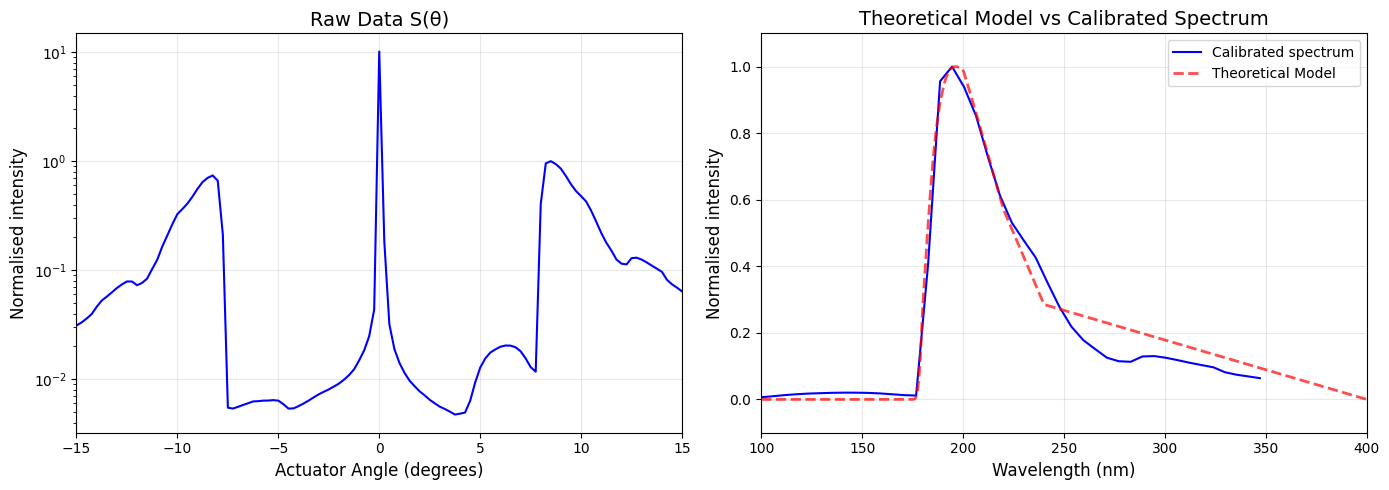

In [8]:
# DATA TAKEN WITHOUT VACUUM - DATA AND THEORETICAL MODEL COMPARISON

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks


def actuator_angle_to_wavelength(theta_deg):
    # Equation 20 of Max's report: m * lambda = 2 * d * cos(phi) * sin(gamma * (theta - theta0))

    d = 835.5          # nm (1 / 1200 lines/mm)
    phi = 35           # degrees (half deviation angle)
    gamma = 1.0028     # actuator scaling factor, Max's : 1.0028
    theta0 = 0.35      # degrees (angular offset), Max's : 1.502
    m = 1              # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)  # ≈ 1365 nm

    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

# Spectrum from Deuterium Lamp Datasheet
deuterium_wavelengths = np.array([114, 120, 122, 124, 126, 130, 132, 136, 140, 144, 148, 150, 156, 158, 161, 165, 170, 180, 200, 220, 240, 400])
deuterium_intensities = np.array([0, 42, 50, 35, 56, 25, 34, 22, 28, 26, 36, 32, 50, 155, 200, 40, 10, 8, 7, 4, 2, 0])

# Air lenght attenuation as a fonction of wavelenght
attenuation_wavelengths = np.array([50, 100, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400])
attenuation_lengths_m = np.array([1e-6, 10e-6, 0.1e-3, 1e-3, 0.01, 0.5, 5, 75, 750, 5000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000, 50000000, 100000000, 200000000, 300000000, 500000000, 700000000, 1000000000, 1000000000])

def attenuation_length(lambda_nm):
    log_lengths = np.log10(attenuation_lengths_m)
    log_interp = np.interp(lambda_nm, attenuation_wavelengths, log_lengths, left=np.log10(1e-9), right=np.log10(1e12))
    return 10 ** log_interp

def air_transmission(lambda_nm, PATH_LENGTH=0.7):
    L_atten = attenuation_length(lambda_nm)
    L_atten_safe = np.where(L_atten < 1e-15, 1e-15, L_atten)
    return np.exp(-PATH_LENGTH / L_atten_safe)

PDE_CONSTANT = 0.24
PATH_LENGTH = 0.7 # Distance between

def model_spectrum(lambda_nm):
    D = np.interp(lambda_nm, deuterium_wavelengths, deuterium_intensities, left=0, right=0)
    T = air_transmission(lambda_nm, PATH_LENGTH)
    return D * PDE_CONSTANT * T

lambda_range = np.linspace(100, 400, 500)
S_lambda = model_spectrum(lambda_range)
S_lambda_norm = S_lambda / np.max(S_lambda)

# Calibration of the measured data
file_path = r"C:/Users/leaga/OneDrive - USherbrooke/Internship UoM/VUV Monochromator/2. Deuterium Lamp/No vacuum/deuterium_test2.txt"
data = np.loadtxt(file_path, delimiter=',', usecols=(0, 1))

angle = data[:, 0]
photocurrent = data[:, 1]

wavelength_calibrated = actuator_angle_to_wavelength(angle)

# Normalization only within the 100–400 nm range for calibrated data
mask = (wavelength_calibrated >= 100) & (wavelength_calibrated <= 400)
photocurrent_norm = photocurrent / np.max(photocurrent[mask])

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Raw data
axes[0].plot(angle, photocurrent_norm, 'b-', linewidth=1.5)
axes[0].set_xlabel('Actuator Angle (degrees)', fontsize=12)
axes[0].set_ylabel('Normalised intensity', fontsize=12)
axes[0].set_title('Raw Data S(θ)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-15, 15)
axes[0].set_yscale('log')

# Plot 2 : Calibrated data vs theoretical model
axes[1].plot(wavelength_calibrated, photocurrent_norm, 'b-', linewidth=1.5, label='Calibrated spectrum')
axes[1].plot(lambda_range, S_lambda_norm, 'r--', linewidth=2, alpha=0.7, label='Theoretical Model')
axes[1].set_xlabel('Wavelength (nm)', fontsize=12)
axes[1].set_ylabel('Normalised intensity', fontsize=12)
axes[1].set_title('Theoretical Model vs Calibrated Spectrum', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim(100, 400)
axes[1].set_ylim(-0.1,1.1)

plt.tight_layout()

save_path = "C:/Users/leaga/OneDrive - USherbrooke/Internship UoM/VUV Monochromator/2. Deuterium Lamp/No vacuum"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [1]:
# FULL CALIBRATED SPECTRUM (with gamma and theta0 values found in the following cells)

import matplotlib.pyplot as plt
import numpy as np

def actuator_angle_to_wavelength(theta_deg):
    # Equation 20 of Max's report: m * lambda = 2 * d * cos(phi) * sin(gamma * (theta - theta0))

    d = 835.5           # nm (1 / 1200 lines/mm)
    phi = 35            # degrees (half deviation angle)
    gamma = 1.00694     # NEW actuator scaling factor, Max's : 1.0028
    theta0 = -1.02898   # NEW degrees (angular offset), max's : 1.502
    m = 1               # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)  # ≈ 1365 nm

    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

data = np.loadtxt(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\long_run_260717_-15_15_0.01.txt",delimiter=',', usecols=(0, 1))

angle = data[:, 0]
photocurrent = data[:, 1]

wavelength_calibrated = actuator_angle_to_wavelength(angle)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Raw Data (angles)
ax1.plot(angle, photocurrent, 'b-', linewidth=1)
ax1.set_xlabel('Actuator Angle (degrees)', fontsize=12)
ax1.set_ylabel('Photocurrent (A)', fontsize=12)
ax1.set_title('Raw Data: Photocurrent vs Angle', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Plot 2 : Calibrated Spectrum
ax2.plot(wavelength_calibrated, photocurrent, 'r-', linewidth=1)
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Photocurrent (A)', fontsize=12)
ax2.set_title('Spectrum: Eq 20 Calibration', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

calibrated_spectrum_data = np.column_stack((wavelength_calibrated, photocurrent))

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\deuterium_lamp_full_detailed_spectrum.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\long_run_260717_-15_15_0.01.txt not found.

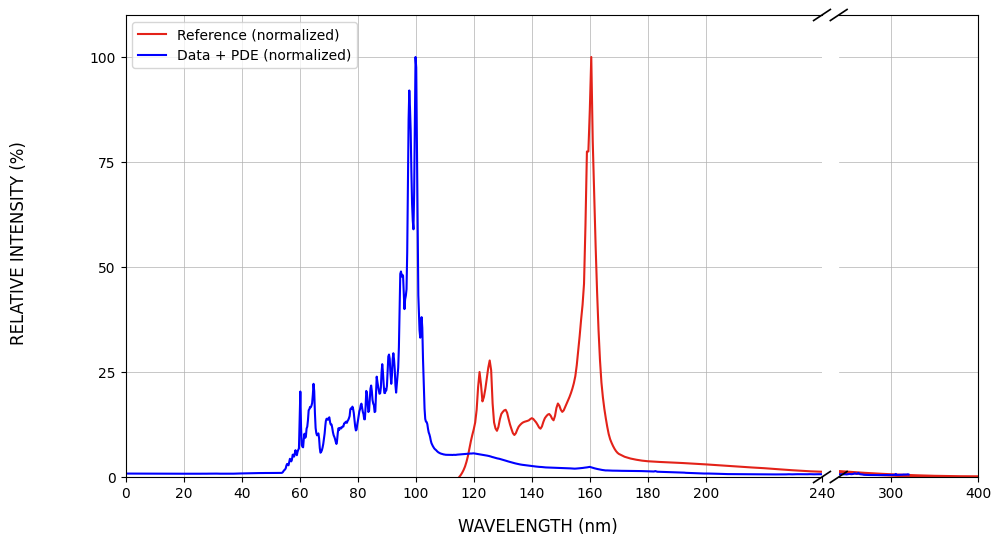

In [48]:
# PLOT OF EXPERIMENTAL DATA VS REFERENCE DATA, NORMALIZED

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# REFERENCE DATA
x_ref = np.array([
    115.0, 115.5, 116.0, 116.5, 117.0, 117.5, 118.0, 118.5, 119.0, 119.5, 120.0, 120.5, 121.0, 121.5, 122.0,
    122.5, 123.0, 123.5, 124.0, 124.5, 125.0, 125.5, 126.0, 126.5, 127.0, 127.5, 128.0, 128.5, 129.0, 129.5,
    130.0, 130.5, 131.0, 131.5, 132.0, 132.5, 133.0, 133.5, 134.0, 134.5, 135.0, 135.5, 136.0, 136.5, 137.0,
    137.5, 138.0, 138.5, 139.0, 139.5, 140.0, 140.5, 141.0, 141.5, 142.0, 142.5, 143.0, 143.5, 144.0, 144.5,
    145.0, 145.5, 146.0, 146.5, 147.0, 147.5, 148.0, 148.5, 149.0, 149.5, 150.0, 150.5, 151.0, 151.5, 152.0,
    152.5, 153.0, 153.5, 154.0, 154.5, 155.0, 155.5, 156.0, 156.5, 157.0, 157.5, 158.0, 158.5, 159.0, 159.5,
    160.0, 160.5, 161.0, 161.5, 162.0, 162.5, 163.0, 163.5, 164.0, 164.5, 165.0, 165.5, 166.0, 166.5, 167.0,
    167.5, 168.0, 168.5, 169.0, 169.5, 170.0,
    172.0, 174.0, 176.0, 178.0, 180.0, 182.0, 184.0, 186.0, 188.0, 190.0, 192.0, 194.0, 196.0, 198.0, 200.0,
    202.0, 204.0, 206.0, 208.0, 210.0, 212.0, 214.0, 216.0, 218.0, 220.0, 222.0, 224.0, 226.0, 228.0, 230.0,
    232.0, 234.0, 236.0, 238.0, 240.0,
    250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0
])
y_ref = np.array([
    0.0, 0.89, 2.0, 3.33, 5.0, 7.24, 10.0, 13.43, 17.0, 20.0, 22.71, 26.0, 32.0, 42.76, 50.0,
    44.0, 36.0, 38.06, 42.0, 47.04, 52.0, 55.5, 50.84, 35.0, 26.0, 23.12, 22.0, 23.84, 27.45, 30.0,
    30.99, 31.72, 32.0, 30.62, 27.68, 25.0, 22.84, 20.86, 20.0, 20.84, 22.57, 24.0, 24.83, 25.51, 26.0,
    26.3, 26.51, 26.72, 27.0, 27.59, 28.0, 27.66, 26.87, 26.0, 24.87, 23.6, 23.0, 24.08, 26.28, 28.0,
    28.94, 29.69, 30.0, 29.22, 27.78, 27.0, 29.07, 32.93, 35.0, 33.96, 32.04, 31.0, 31.71, 33.3, 35.0,
    36.5, 38.12, 40.0, 42.14, 44.7, 48.0, 53.28, 60.0, 67.17, 75.0, 82.03, 92.0, 120.0, 155.0, 155.0,
    175.0, 200.0, 160.0, 135.0, 110.0, 88.22, 70.0, 55.65, 45.0, 37.97, 32.5, 28.0, 23.95, 20.47, 18.0,
    16.27, 14.76, 13.46, 12.39, 11.57, 11.0, 9.63, 8.8, 8.23, 7.79, 7.5, 7.31, 7.17, 7.05, 6.93,
    6.8, 6.65, 6.5, 6.34, 6.17, 6.0, 5.81, 5.61, 5.39, 5.19, 5.0, 4.83, 4.68, 4.52, 4.37,
    4.2, 4.01, 3.8, 3.59, 3.38, 3.2, 3.03, 2.87, 2.71, 2.59, 2.5, 2.2, 1.91, 1.65, 1.4,
    1.18, 0.97, 0.79, 0.62, 0.48, 0.35, 0.24, 0.16, 0.09, 0.04, 0.01, 0.0
])

# PDE DATA
wl_pde = np.array([120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200])
vals_pde = np.array([11, 12.5, 15.0, 19.0, 22.0, 24, 23.5, 23, 17, 23.5, 23.5, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0])

# RAW EXPERIMENTAL DATA
path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\long_run_260717_-15_15_0.01.txt"
data = np.loadtxt(path, delimiter=',', usecols=(0, 1))
angle = data[:, 0]
photocurrent = data[:, 1]

# CONVERSION TO WAVELENGTH
d = 835.5
phi = 35
gamma = 1.0028
theta0 = 1.502
C = 2 * d * np.cos(np.radians(phi))
wavelength_final = C * np.sin(gamma * (np.radians(angle) - np.radians(theta0)))

# PDE CORRECTION
pde_final = np.interp(wavelength_final, wl_pde, vals_pde, left=vals_pde[0], right=vals_pde[-1])
photocurrent_corrected = photocurrent / pde_final

# STANDARDIZATION (100 base, proportional to the 2nd experimental peak)
peaks, _ = find_peaks(photocurrent_corrected, distance=20)
sorted_peaks = sorted(peaks, key=lambda idx: photocurrent_corrected[idx], reverse=True)
val_2nd_peak_exp = photocurrent_corrected[sorted_peaks[1]]

scale_factor = 100.0 / val_2nd_peak_exp
photocurrent_normalise = photocurrent_corrected * scale_factor

y_ref_normalise = y_ref * (100.0 / np.max(y_ref))

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(11, 6), gridspec_kw={'width_ratios': [5, 1]})
fig.subplots_adjust(wspace=0.04)

ax1.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=1.5, label='Reference (normalized)')
ax1.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5, label='Data + PDE (normalized)')

ax2.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=2.5)
ax2.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5)

ax1.set_xlim(0, 240)
ax2.set_xlim(240, 400)
ax1.set_ylim(0.1, 110)

ax1.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 240])
ax2.set_xticks([300, 400])
ax1.set_yticks([0, 25, 50, 75, 100])

ax1.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)
ax2.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

d_tick = .012
kwargs = dict(transform=ax1.transAxes, color='black', clip_on=False, linewidth=1.2)
ax1.plot((1 - d_tick, 1 + d_tick), (-d_tick, +d_tick), **kwargs)
ax1.plot((1 - d_tick, 1 + d_tick), (1 - d_tick, 1 + d_tick), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d_tick * 5, +d_tick * 5), (-d_tick, +d_tick), **kwargs)
ax2.plot((-d_tick * 5, +d_tick * 5), (1 - d_tick, 1 + d_tick), **kwargs)

ax1.legend(loc='upper left')
fig.text(0.5, 0.02, 'WAVELENGTH (nm)', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'RELATIVE INTENSITY (%)', va='center', rotation='vertical', fontsize=12)

plt.show()

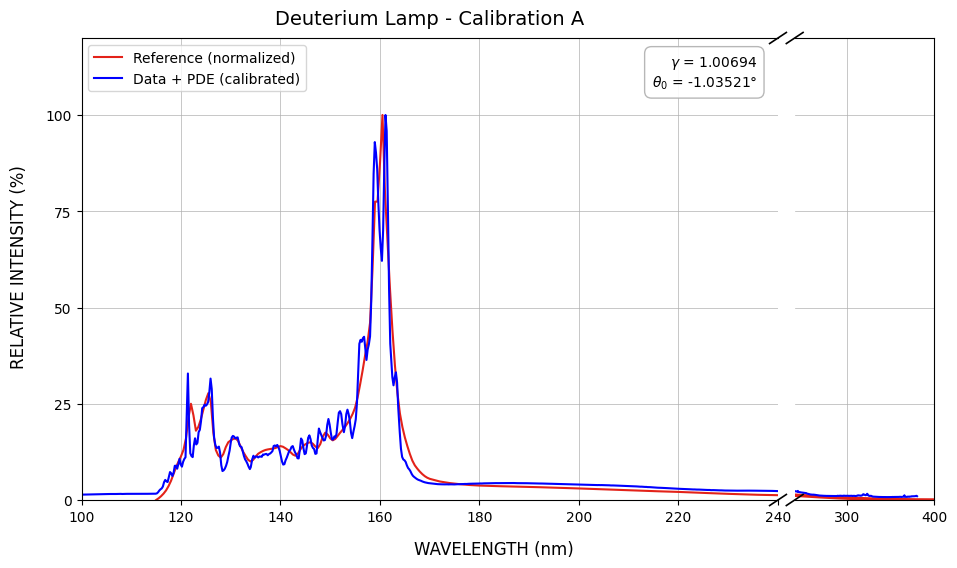

In [104]:
# CALIBRATION A

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# REFERENCE DATA
x_ref = np.array([
    115.0, 115.5, 116.0, 116.5, 117.0, 117.5, 118.0, 118.5, 119.0, 119.5, 120.0, 120.5, 121.0, 121.5, 122.0,
    122.5, 123.0, 123.5, 124.0, 124.5, 125.0, 125.5, 126.0, 126.5, 127.0, 127.5, 128.0, 128.5, 129.0, 129.5,
    130.0, 130.5, 131.0, 131.5, 132.0, 132.5, 133.0, 133.5, 134.0, 134.5, 135.0, 135.5, 136.0, 136.5, 137.0,
    137.5, 138.0, 138.5, 139.0, 139.5, 140.0, 140.5, 141.0, 141.5, 142.0, 142.5, 143.0, 143.5, 144.0, 144.5,
    145.0, 145.5, 146.0, 146.5, 147.0, 147.5, 148.0, 148.5, 149.0, 149.5, 150.0, 150.5, 151.0, 151.5, 152.0,
    152.5, 153.0, 153.5, 154.0, 154.5, 155.0, 155.5, 156.0, 156.5, 157.0, 157.5, 158.0, 158.5, 159.0, 159.5,
    160.0, 160.5, 161.0, 161.5, 162.0, 162.5, 163.0, 163.5, 164.0, 164.5, 165.0, 165.5, 166.0, 166.5, 167.0,
    167.5, 168.0, 168.5, 169.0, 169.5, 170.0,
    172.0, 174.0, 176.0, 178.0, 180.0, 182.0, 184.0, 186.0, 188.0, 190.0, 192.0, 194.0, 196.0, 198.0, 200.0,
    202.0, 204.0, 206.0, 208.0, 210.0, 212.0, 214.0, 216.0, 218.0, 220.0, 222.0, 224.0, 226.0, 228.0, 230.0,
    232.0, 234.0, 236.0, 238.0, 240.0,
    250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0
])
y_ref = np.array([
    0.0, 0.89, 2.0, 3.33, 5.0, 7.24, 10.0, 13.43, 17.0, 20.0, 22.71, 26.0, 32.0, 42.76, 50.0,
    44.0, 36.0, 38.06, 42.0, 47.04, 52.0, 55.5, 50.84, 35.0, 26.0, 23.12, 22.0, 23.84, 27.45, 30.0,
    30.99, 31.72, 32.0, 30.62, 27.68, 25.0, 22.84, 20.86, 20.0, 20.84, 22.57, 24.0, 24.83, 25.51, 26.0,
    26.3, 26.51, 26.72, 27.0, 27.59, 28.0, 27.66, 26.87, 26.0, 24.87, 23.6, 23.0, 24.08, 26.28, 28.0,
    28.94, 29.69, 30.0, 29.22, 27.78, 27.0, 29.07, 32.93, 35.0, 33.96, 32.04, 31.0, 31.71, 33.3, 35.0,
    36.5, 38.12, 40.0, 42.14, 44.7, 48.0, 53.28, 60.0, 67.17, 75.0, 82.03, 92.0, 120.0, 155.0, 155.0,
    175.0, 200.0, 160.0, 135.0, 110.0, 88.22, 70.0, 55.65, 45.0, 37.97, 32.5, 28.0, 23.95, 20.47, 18.0,
    16.27, 14.76, 13.46, 12.39, 11.57, 11.0, 9.63, 8.8, 8.23, 7.79, 7.5, 7.31, 7.17, 7.05, 6.93,
    6.8, 6.65, 6.5, 6.34, 6.17, 6.0, 5.81, 5.61, 5.39, 5.19, 5.0, 4.83, 4.68, 4.52, 4.37,
    4.2, 4.01, 3.8, 3.59, 3.38, 3.2, 3.03, 2.87, 2.71, 2.59, 2.5, 2.2, 1.91, 1.65, 1.4,
    1.18, 0.97, 0.79, 0.62, 0.48, 0.35, 0.24, 0.16, 0.09, 0.04, 0.01, 0.0
])

y_ref_norm = y_ref * (100.0 / np.max(y_ref)) # Normalization of reference

# PDE DATA
wl_pde = np.array([120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200])
vals_pde = np.array([11, 12.5, 15.0, 19.0, 22.0, 24, 23.5, 23, 17, 23.5, 23.5, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0])

# RAW EXPERIMENTAL DATA
path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\long_run_260717_-15_15_0.01.txt"
data = np.loadtxt(path, delimiter=',', usecols=(0, 1))
angle = data[:, 0]
photocurrent = data[:, 1]

# PHYSICAL CONVERSION FUNCTION - EQ 20 OF MAX'S REPORT
def get_wavelength(theta_deg, gamma, theta0):
    d = 835.5
    phi = 35
    C = 2 * d * np.cos(np.radians(phi))
    return C * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))

# OBJECTIVE FUNCTION FOR X-AXIS ALIGNMENT
def objective_function(params):
    gamma, theta0 = params
    w_calib = get_wavelength(angle, gamma, theta0)

    # Apply dynamic PDE correction
    pde_interp = np.interp(w_calib, wl_pde, vals_pde, left=vals_pde[0], right=vals_pde[-1])
    y_corrected = photocurrent / pde_interp

    # Focus optimization strictly on the primary peak features region
    mask_fit = (w_calib >= 115) & (w_calib <= 170)
    if np.sum(mask_fit) < 10:
        return 1e10

    w_fit = w_calib[mask_fit]
    y_fit = y_corrected[mask_fit]

    # Map reference onto current data wavelength array
    y_ref_lookup = np.interp(w_fit, x_ref, y_ref_norm)
    y_fit_scaled = y_fit * (100.0 / np.max(y_fit))

    # Minimize residual sum of squares
    return np.sum((y_fit_scaled - y_ref_lookup) ** 2)

# OPTIMIZATION RUN WITH FIXED PHYSICAL ALIGNMENT OVERRIDE
init_guess = [1.00694, -1.03520] # gamma and theta0
bounds = [(0.98, 1.05), (-2.0, -0.5)] # angles

result = minimize(objective_function, init_guess, bounds=bounds, method='L-BFGS-B')
gamma_opt, theta0_opt = result.x

# FINAL VALUE CORRECTION & TARGETED INTENSITY NORMALIZATION
wavelength_final = get_wavelength(angle, gamma_opt, theta0_opt)
pde_final = np.interp(wavelength_final, wl_pde, vals_pde, left=vals_pde[0], right=vals_pde[-1])
photocurrent_corrected = photocurrent / pde_final

mask_peaks = (wavelength_final >= 115) & (wavelength_final <= 200)
val_doublet_max = np.max(photocurrent_corrected[mask_peaks])

photocurrent_normalise = photocurrent_corrected * (100.0 / val_doublet_max)
y_ref_normalise = y_ref * (100.0 / np.max(y_ref))

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(11, 6), gridspec_kw={'width_ratios': [5, 1]})
fig.subplots_adjust(wspace=0.04)

ax1.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=1.5, label='Reference (normalized)')
ax1.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5, label='Data + PDE (calibrated)')

ax2.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=2.5)
ax2.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5)

ax1.set_xlim(100, 240)
ax2.set_xlim(240, 400)
ax1.set_ylim(0.1, 120)

ax1.set_xticks([100, 120, 140, 160, 180, 200, 220, 240])
ax2.set_xticks([300, 400])
ax1.set_yticks([0, 25, 50, 75, 100])

ax1.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)
ax2.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax1.set_title('Deuterium Lamp - Calibration A', fontsize=14, loc='center', pad=10)

d_tick = .012
kwargs = dict(transform=ax1.transAxes, color='black', clip_on=False, linewidth=1.2)
ax1.plot((1 - d_tick, 1 + d_tick), (-d_tick, +d_tick), **kwargs)
ax1.plot((1 - d_tick, 1 + d_tick), (1 - d_tick, 1 + d_tick), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d_tick * 5, +d_tick * 5), (-d_tick, +d_tick), **kwargs)
ax2.plot((-d_tick * 5, +d_tick * 5), (1 - d_tick, 1 + d_tick), **kwargs)

info_text = f"$\\gamma$ = {gamma_opt:.5f}\n$\\theta_0$ = {theta0_opt:.5f}°"
ax1.text(0.97, 0.965, info_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#b0b0b0', alpha=0.9))

ax1.legend(loc='upper left')
fig.text(0.5, 0.02, 'WAVELENGTH (nm)', ha='center', fontsize=12)
fig.text(0.06, 0.5, 'RELATIVE INTENSITY (%)', va='center', rotation='vertical', fontsize=12)

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\data_pde_corrected_vs_reference_calibrationA.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

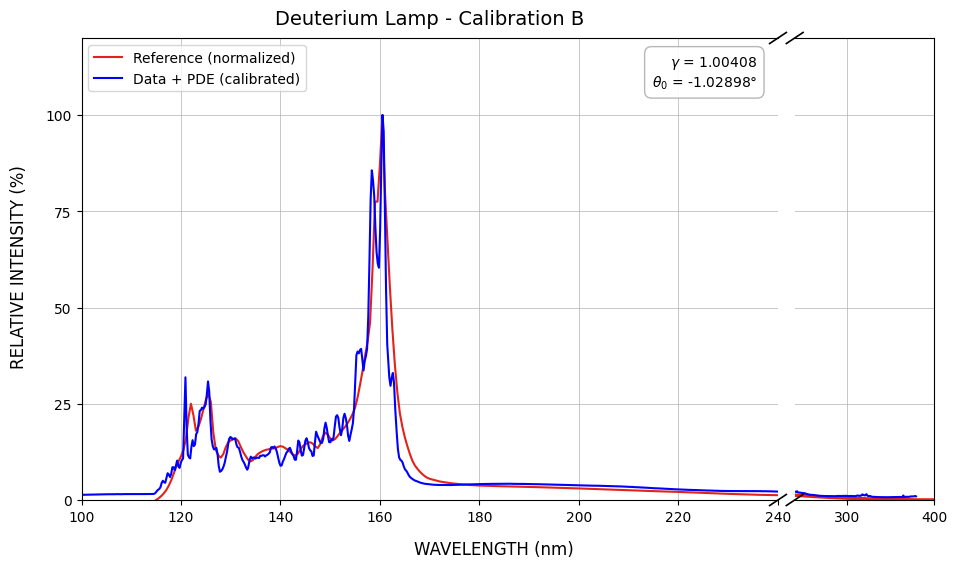

In [105]:
# CALIBRATION B

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.signal import find_peaks

# REFERENCE DATA
x_ref = np.array([
    115.0, 115.5, 116.0, 116.5, 117.0, 117.5, 118.0, 118.5, 119.0, 119.5, 120.0, 120.5, 121.0, 121.5, 122.0,
    122.5, 123.0, 123.5, 124.0, 124.5, 125.0, 125.5, 126.0, 126.5, 127.0, 127.5, 128.0, 128.5, 129.0, 129.5,
    130.0, 130.5, 131.0, 131.5, 132.0, 132.5, 133.0, 133.5, 134.0, 134.5, 135.0, 135.5, 136.0, 136.5, 137.0,
    137.5, 138.0, 138.5, 139.0, 139.5, 140.0, 140.5, 141.0, 141.5, 142.0, 142.5, 143.0, 143.5, 144.0, 144.5,
    145.0, 145.5, 146.0, 146.5, 147.0, 147.5, 148.0, 148.5, 149.0, 149.5, 150.0, 150.5, 151.0, 151.5, 152.0,
    152.5, 153.0, 153.5, 154.0, 154.5, 155.0, 155.5, 156.0, 156.5, 157.0, 157.5, 158.0, 158.5, 159.0, 159.5,
    160.0, 160.5, 161.0, 161.5, 162.0, 162.5, 163.0, 163.5, 164.0, 164.5, 165.0, 165.5, 166.0, 166.5, 167.0,
    167.5, 168.0, 168.5, 169.0, 169.5, 170.0,
    172.0, 174.0, 176.0, 178.0, 180.0, 182.0, 184.0, 186.0, 188.0, 190.0, 192.0, 194.0, 196.0, 198.0, 200.0,
    202.0, 204.0, 206.0, 208.0, 210.0, 212.0, 214.0, 216.0, 218.0, 220.0, 222.0, 224.0, 226.0, 228.0, 230.0,
    232.0, 234.0, 236.0, 238.0, 240.0,
    250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0
])
y_ref = np.array([
    0.0, 0.89, 2.0, 3.33, 5.0, 7.24, 10.0, 13.43, 17.0, 20.0, 22.71, 26.0, 32.0, 42.76, 50.0,
    44.0, 36.0, 38.06, 42.0, 47.04, 52.0, 55.5, 50.84, 35.0, 26.0, 23.12, 22.0, 23.84, 27.45, 30.0,
    30.99, 31.72, 32.0, 30.62, 27.68, 25.0, 22.84, 20.86, 20.0, 20.84, 22.57, 24.0, 24.83, 25.51, 26.0,
    26.3, 26.51, 26.72, 27.0, 27.59, 28.0, 27.66, 26.87, 26.0, 24.87, 23.6, 23.0, 24.08, 26.28, 28.0,
    28.94, 29.69, 30.0, 29.22, 27.78, 27.0, 29.07, 32.93, 35.0, 33.96, 32.04, 31.0, 31.71, 33.3, 35.0,
    36.5, 38.12, 40.0, 42.14, 44.7, 48.0, 53.28, 60.0, 67.17, 75.0, 82.03, 92.0, 120.0, 155.0, 155.0,
    175.0, 200.0, 160.0, 135.0, 110.0, 88.22, 70.0, 55.65, 45.0, 37.97, 32.5, 28.0, 23.95, 20.47, 18.0,
    16.27, 14.76, 13.46, 12.39, 11.57, 11.0, 9.63, 8.8, 8.23, 7.79, 7.5, 7.31, 7.17, 7.05, 6.93,
    6.8, 6.65, 6.5, 6.34, 6.17, 6.0, 5.81, 5.61, 5.39, 5.19, 5.0, 4.83, 4.68, 4.52, 4.37,
    4.2, 4.01, 3.8, 3.59, 3.38, 3.2, 3.03, 2.87, 2.71, 2.59, 2.5, 2.2, 1.91, 1.65, 1.4,
    1.18, 0.97, 0.79, 0.62, 0.48, 0.35, 0.24, 0.16, 0.09, 0.04, 0.01, 0.0
])
y_ref_norm = y_ref * (100.0 / np.max(y_ref))

# PDE DATA
wl_pde = np.array([120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200])
vals_pde = np.array([11, 12.5, 15.0, 19.0, 22.0, 24, 23.5, 23, 17, 23.5, 23.5, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0])

# RAW EXPERIMENTAL DATA
path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\long_run_260717_-15_15_0.01.txt"
data = np.loadtxt(path, delimiter=',', usecols=(0, 1))
angle = data[:, 0]
photocurrent = data[:, 1]

# PHYSICAL CONVERSION FUNCTION
def get_wavelength(theta_deg, gamma, theta0):
    d = 835.5
    phi = 35
    C = 2 * d * np.cos(np.radians(phi))
    return C * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))

# OBJECTIVE FUNCTION FOR X-AXIS ALIGNMENT
def objective_function(params):
    gamma, theta0 = params
    w_calib = get_wavelength(angle, gamma, theta0)

    pde_interp = np.interp(w_calib, wl_pde, vals_pde, left=vals_pde[0], right=vals_pde[-1])
    y_corrected = photocurrent / pde_interp

    # Target strictly the core of the 160 nm peak
    mask_fit = (w_calib >= 155) & (w_calib <= 165)
    if np.sum(mask_fit) < 10:
        return 1e10

    w_fit = w_calib[mask_fit]
    y_fit = y_corrected[mask_fit]

    y_ref_lookup = np.interp(w_fit, x_ref, y_ref_norm)
    y_fit_scaled = y_fit * (100.0 / np.max(y_fit))

    return np.sum((y_fit_scaled - y_ref_lookup) ** 2)

# OPTIMIZATION RUN WITH FIXED PHYSICAL ALIGNMENT OVERRIDE
init_guess = [1.00694, -1.03520]
bounds = [(0.98, 1.05), (-2.0, -0.5)]

result = minimize(objective_function, init_guess, bounds=bounds, method='L-BFGS-B')
gamma_opt, theta0_raw = result.x

# Manual override according to visual spectral alignment:
theta0_opt = theta0_raw + 0.025

# FINAL VALUE CORRECTION & TARGETED INTENSITY NORMALIZATION
wavelength_final = get_wavelength(angle, gamma_opt, theta0_opt)
pde_final = np.interp(wavelength_final, wl_pde, vals_pde, left=vals_pde[0], right=vals_pde[-1])
photocurrent_corrected = photocurrent / pde_final

mask_peaks = (wavelength_final >= 115) & (wavelength_final <= 200)
peaks_in_zone, _ = find_peaks(photocurrent_corrected[mask_peaks], distance=10)
peaks_global_indices = np.where(mask_peaks)[0][peaks_in_zone]

highest_peak_idx = max(peaks_global_indices, key=lambda idx: photocurrent_corrected[idx])
val_doublet_max = photocurrent_corrected[highest_peak_idx]

scale_factor = 100.0 / val_doublet_max
photocurrent_normalise = photocurrent_corrected * scale_factor
y_ref_normalise = y_ref * (100.0 / np.max(y_ref))

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(11, 6), gridspec_kw={'width_ratios': [5, 1]})
fig.subplots_adjust(wspace=0.04)

ax1.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=1.5, label='Reference (normalized)')
ax1.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5, label='Data + PDE (calibrated)')

ax2.plot(x_ref, y_ref_normalise, color='#e32219', linewidth=2.5)
ax2.plot(wavelength_final, photocurrent_normalise, color='blue', linestyle='-', linewidth=1.5)

ax1.set_xlim(100, 240)
ax2.set_xlim(240, 400)
ax1.set_ylim(0.1, 120)

ax1.set_xticks([100, 120, 140, 160, 180, 200, 220, 240])
ax2.set_xticks([300, 400])
ax1.set_yticks([0, 25, 50, 75, 100])

ax1.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)
ax2.grid(True, color='#b0b0b0', linestyle='-', linewidth=0.5)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)
ax1.set_title('Deuterium Lamp - Calibration B', fontsize=14, loc='center', pad=10)

d_tick = .012
kwargs = dict(transform=ax1.transAxes, color='black', clip_on=False, linewidth=1.2)
ax1.plot((1 - d_tick, 1 + d_tick), (-d_tick, +d_tick), **kwargs)
ax1.plot((1 - d_tick, 1 + d_tick), (1 - d_tick, 1 + d_tick), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d_tick * 5, +d_tick * 5), (-d_tick, +d_tick), **kwargs)
ax2.plot((-d_tick * 5, +d_tick * 5), (1 - d_tick, 1 + d_tick), **kwargs)

info_text = f"$\\gamma$ = {gamma_opt:.5f}\n$\\theta_0$ = {theta0_opt:.5f}°"
ax1.text(0.97, 0.965, info_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#b0b0b0', alpha=0.9))

ax1.legend(loc='upper left')

fig.text(0.5, 0.02, 'WAVELENGTH (nm)', ha='center', fontsize=12)
fig.text(0.06, 0.5, 'RELATIVE INTENSITY (%)', va='center', rotation='vertical', fontsize=12)

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Calibration\data_pde_corrected_vs_reference_calibrationB.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [60]:
# CALIBRATION A AND B COMPARISON

import numpy as np

# Constant optical coefficients from the setup
d, phi = 835.5, 35
C_OPTICAL = 2 * d * np.cos(np.radians(phi))

# SET PARAMETERS FOR BOTH CALIBRATIONS
# Calibration A: Global fit results
gamma_A = 1.00694
theta0_A = -1.02898

# Calibration B: Targeted peak fit + manual override results
gamma_B = 1.00408
theta0_B = -1.02898 # raw + manual offset (0.025)

# DEFINE DIRECT AND INVERSE TRANSFORMATION FUNCTIONS
def get_wavelength(theta_deg, gamma, theta0):
    return C_OPTICAL * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))

def get_angle_inverse(wavelength_nm, gamma, theta0):
    alpha = np.arcsin(wavelength_nm / C_OPTICAL)
    theta_rad = (alpha / gamma) + np.radians(theta0)
    return np.degrees(theta_rad)

# CHOSEN TARGET WAVELENGTHS FOR COMPARISON
target_wavelengths = [128.0, 178.0]

print("CALIBRATION COMPARISON")
for wl_start in target_wavelengths:
    # Step A: Find the mechanical angle corresponding to wl_start using Calibration A
    angle_calc = get_angle_inverse(wl_start, gamma_A, theta0_A)

    # Step B: Pass this calculated angle into Calibration B to see the new wavelength
    wl_end = get_wavelength(angle_calc, gamma_B, theta0_B)

    # Step C: Calculate the delta shift
    delta_wl = wl_end - wl_start

    # Display the results
    print(f"\nTarget Wavelength: {wl_start} nm")
    print(f" -> Equivalent Angle (Calib A): {angle_calc:.5f}°")
    print(f" -> Resulting Wavelength (Calib B): {wl_end:.3f} nm")
    print(f" -> Shift (Delta Lambda): {delta_wl:.3f} nm")

CALIBRATION COMPARISON

Target Wavelength: 128.0 nm
 -> Equivalent Angle (Calib A): 4.29974°
 -> Resulting Wavelength (Calib B): 127.638 nm
 -> Shift (Delta Lambda): -0.362 nm

Target Wavelength: 178.0 nm
 -> Equivalent Angle (Calib A): 6.39146°
 -> Resulting Wavelength (Calib B): 177.497 nm
 -> Shift (Delta Lambda): -0.503 nm


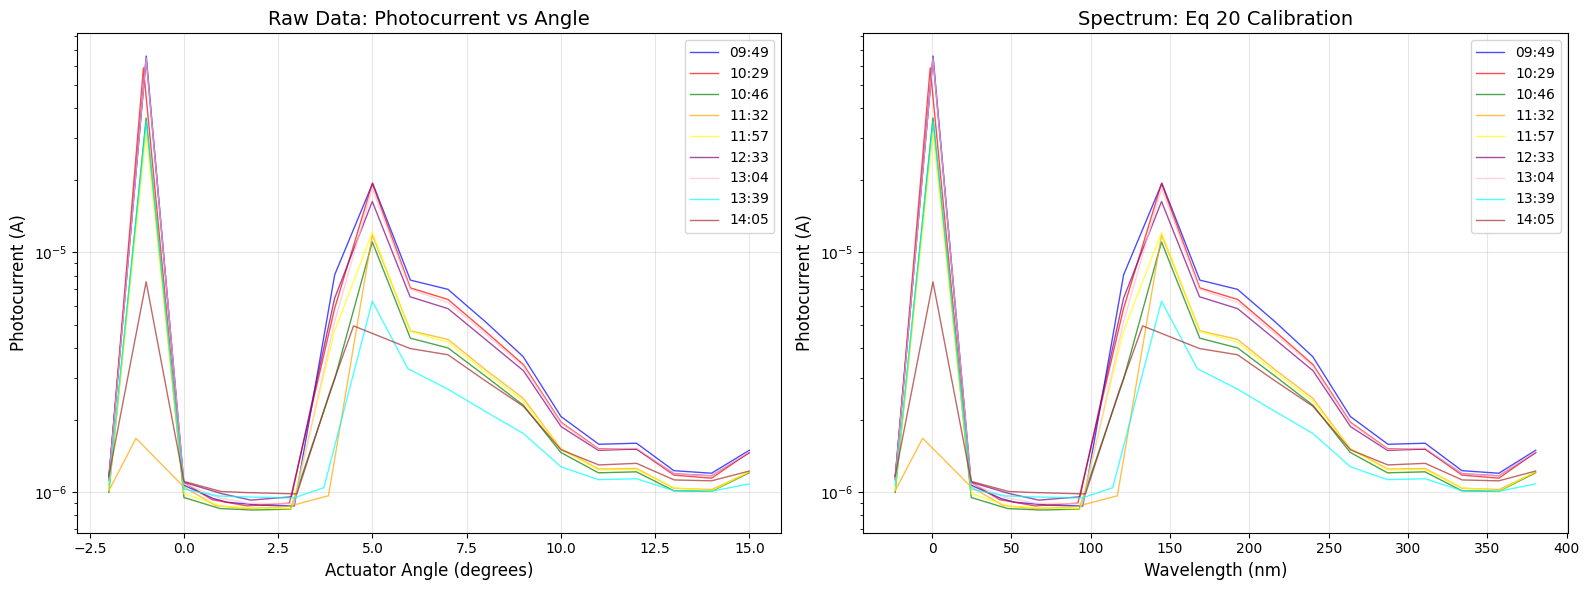

In [25]:
# 1ST STABILITY TEST - FEW MEASUREMENRS SCANNING A SELECTED RANGE OF ANGLES OVER A DAY - 2026/07/20

import matplotlib.pyplot as plt
import numpy as np
import os

def actuator_angle_to_wavelength(theta_deg):
    # Equation 20 of Max's report: m * lambda = 2 * d * cos(phi) * sin(gamma * (theta - theta0))

    d = 835.5          # nm (1 / 1200 lines/mm)
    phi = 35           # degrees (half deviation angle)
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1              # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)  # ≈ 1365 nm
    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

# EXPERIMENTAL DATA
base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability"

file_configs = [
    ("stability_20260720_no1_-2_15_1.txt", "09:49", 'blue'),
    ("stability_20260720_no2_-2_15_1.txt", "10:29", 'red'),
    ("stability_20260720_no3_-2_15_1.txt", "10:46", 'green'),
    ("stability_20260720_no4_-2_15_1.txt", "11:32", 'orange'),
    ("stability_20260720_no5_-2_15_1.txt", "11:57", 'yellow'),
    ("stability_20260720_no6_-2_15_1.txt", "12:33", 'purple'),
    ("stability_20260720_no7_-2_15_1.txt", "13:04", 'pink'),
    ("stability_20260720_no8_-2_15_1.txt", "13:39", 'cyan'),
    ("stability_20260720_no9_-2_15_1.txt", "14:05", 'brown')
]

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

calibrated_data_list = []

for filename, label, color in file_configs:
    filepath = os.path.join(base_path, filename)

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        angle = data[:, 0]
        photocurrent = data[:, 1]

        wavelength_calibrated = actuator_angle_to_wavelength(angle)

        calibrated_data_list.append((wavelength_calibrated, photocurrent, label))

        # Plot 1: Raw Data (angles) - stacked
        ax1.plot(angle, photocurrent, color=color, linewidth=1, label=label, alpha=0.7)

        # Plot 2: Calibrated Spectrum - stacked
        ax2.plot(wavelength_calibrated, photocurrent, color=color, linewidth=1, label=label, alpha=0.7)

    except FileNotFoundError:
        print(f"File not found: {filename}")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

# Plot 1 config
ax1.set_xlabel('Actuator Angle (degrees)', fontsize=12)
ax1.set_ylabel('Photocurrent (A)', fontsize=12)
ax1.set_title('Raw Data: Photocurrent vs Angle', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)

# Plot 2 config
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Photocurrent (A)', fontsize=12)
ax2.set_title('Spectrum: Eq 20 Calibration', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)

plt.tight_layout()

save_path = os.path.join(base_path, "stability_overlay_comparison_1-9.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

09:49: 0.0 min, photocurrent=7.0091e-06 A
10:29: 40.0 min, photocurrent=6.3567e-06 A
10:46: 57.0 min, photocurrent=3.9923e-06 A
11:32: 103.0 min, photocurrent=4.3335e-06 A
11:57: 128.0 min, photocurrent=4.2153e-06 A
12:33: 164.0 min, photocurrent=5.8224e-06 A
13:04: 195.0 min, photocurrent=6.1707e-06 A
13:39: 230.0 min, photocurrent=2.6875e-06 A
14:05: 256.0 min, photocurrent=3.7397e-06 A


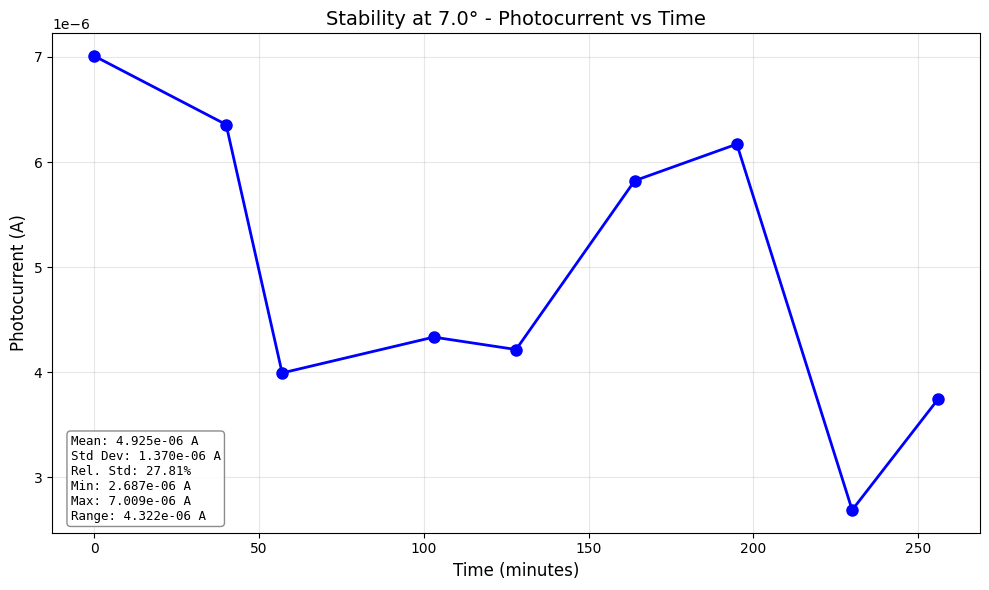

In [114]:
# PLOT TO VISUALISE THE VARIATION IN INTENSITY OVER TIME AT A SELECTED ANGLE

import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime

def actuator_angle_to_wavelength(theta_deg):
    # Equation 20: m * lambda = 2 * d * cos(phi) * sin(gamma * (theta - theta0))

    d = 835.5          # nm (1 / 1200 lines/mm)
    phi = 35           # degrees (half deviation angle)
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1              # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)  # ≈ 1365 nm
    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

# EXPERIMENTAL DATA
base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability"

file_configs = [
    ("stability_20260720_no1_-2_15_1.txt", "09:49"),
    ("stability_20260720_no2_-2_15_1.txt", "10:29"),
    ("stability_20260720_no3_-2_15_1.txt", "10:46"),
    ("stability_20260720_no4_-2_15_1.txt", "11:32"),
    ("stability_20260720_no5_-2_15_1.txt", "11:57"),
    ("stability_20260720_no6_-2_15_1.txt", "12:33"),
    ("stability_20260720_no7_-2_15_1.txt", "13:04"),
    ("stability_20260720_no8_-2_15_1.txt", "13:39"),
    ("stability_20260720_no9_-2_15_1.txt", "14:05")
]

# Target angle
target_angle = 7.0

# Time reference
first_time = datetime.strptime(file_configs[0][1], "%H:%M")

# Store data
time_minutes = []
photocurrent_values = []

for filename, time_str in file_configs:
    filepath = os.path.join(base_path, filename)

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        angle = data[:, 0]
        photocurrent = data[:, 1]

        # Find the index closest to the target angle
        idx = np.argmin(np.abs(angle - target_angle))
        pc_value = photocurrent[idx]

        # Calculate the time in minutes since the first measurement
        current_time = datetime.strptime(time_str, "%H:%M")
        minutes = (current_time - first_time).total_seconds() / 60.0

        time_minutes.append(minutes)
        photocurrent_values.append(pc_value)

        print(f"{time_str}: {minutes:.1f} min, photocurrent={pc_value:.4e} A")

    except Exception as e:
        print(f"Error for {filename}: {e}")

# PLOTTING
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
        fontsize=9, family='monospace')


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time_minutes, photocurrent_values, 'bo-', linewidth=2, markersize=8)

ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('Photocurrent (A)', fontsize=12)
ax.set_title(f'Stability at {target_angle}° - Photocurrent vs Time', fontsize=14)
ax.grid(True, alpha=0.3)

# Calculation of statistics
mean_pc = np.mean(photocurrent_values)
std_pc = np.std(photocurrent_values)
min_pc = np.min(photocurrent_values)
max_pc = np.max(photocurrent_values)
range_pc = max_pc - min_pc
rel_std = (std_pc / mean_pc) * 100  # écart-type relatif en %

# Printing statistics
stats_text = (
    f'Mean: {mean_pc:.3e} A\n'
    f'Std Dev: {std_pc:.3e} A\n'
    f'Rel. Std: {rel_std:.2f}%\n'
    f'Min: {min_pc:.3e} A\n'
    f'Max: {max_pc:.3e} A\n'
    f'Range: {range_pc:.3e} A'
)

ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
        fontsize=9, family='monospace')

plt.tight_layout()

save_path = os.path.join(base_path, f"stability_at_{target_angle}deg_analysis.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

STABILITY REPORT
Total Duration: 6.58 hours
Global Mean Photocurrent: 4.477987e-04 A


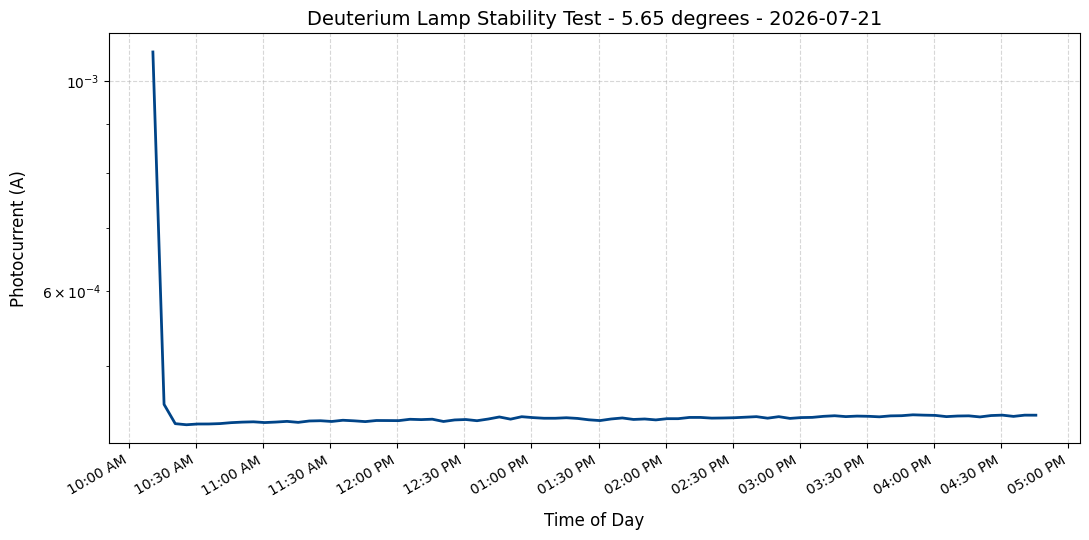

In [111]:
# 2ND STABILITY TEST - ONE DAY MEASUREMENT, DATA ACQUISITION EVERY 5MIN AT A SELECTED ANGLE - 2026/07/21

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# LOAD DATA
path_file = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\test_stability_20260721.txt"
df = pd.read_csv(path_file)

# Convert timestamps to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# EXTRACT STATS & DATE FOR THE TITLE
experiment_date = df['timestamp'].iloc[0].strftime('%Y-%m-%d')

duration_hours = df['t_min'].max() / 60
current_mean_total = df['current_mean_A'].mean()

print("STABILITY REPORT")
print(f"Total Duration: {duration_hours:.2f} hours")
print(f"Global Mean Photocurrent: {current_mean_total:.6e} A")

# PLOTTING
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(df['timestamp'], df['current_mean_A'], color='#004488', linewidth=2)

ax.set_title(f'Deuterium Lamp Stability Test - 5.65 degrees - {experiment_date}', fontsize=14)
ax.set_xlabel('Time of Day', fontsize=12, labelpad=10)
ax.set_ylabel('Photocurrent (A)', fontsize=12, labelpad=10)
ax.set_yscale('log')

ax.grid(True, linestyle='--', alpha=0.5, color='#b0b0b0')

# TIME AXIS FORMATTING (12-hour system, hour & half-hour ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
fig.autofmt_xdate(rotation=30, ha='right')

save_path = os.path.join(r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\stability_at_5.65deg_plot_data_5min_intervals_20260721.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

LINEAR FIT REPORT
New Start Time: 10:25 AM
Mean Current (Filtered Window): 4.397487e-04 A
Absolute Slope: 1.303681e-06 A/hour
Relative Slope (%): 0.2965 % per hour
Relative Slope (%): 0.004941 % per minute

STEP-TO-STEP VOLATILITY REPORT
Number of steps analyzed: 76
Average step variation: +0.0309 %
Step variation standard deviation: 0.2418 %


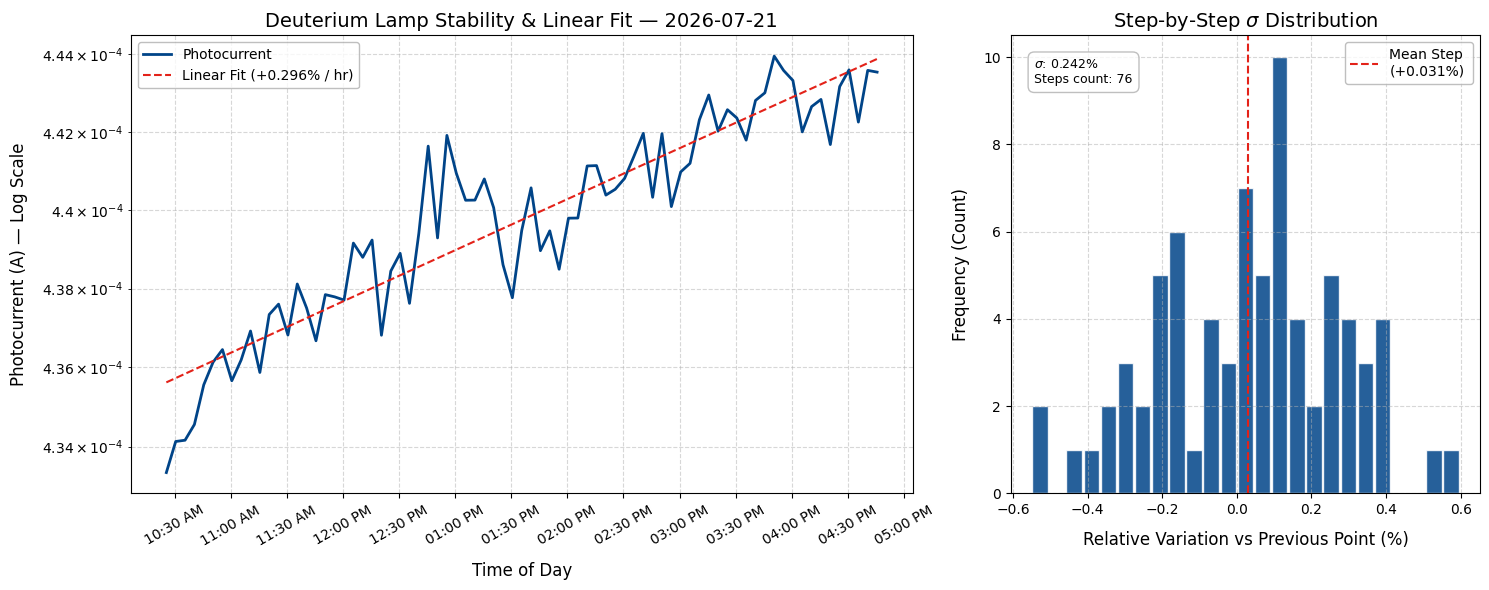

In [112]:
# STABILITY ANALYSIS - LINEAR FIT & VOLATILITY HISTOGRAM

import os
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# LOAD DATA
path_file = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\test_stability_20260721.txt"
df = pd.read_csv(path_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# FILTER DATA (Start at 10:25 AM, when lamp is "stable")
df_filtered = df[df['t_min'] >= 15.0].copy()

# CALCULATE LINEAR FIT & SLOPE IN %
# Convert filtered timestamps to numerical minutes/hours from the new start point
time_minutes = df_filtered['t_min'].values - df_filtered['t_min'].min()
time_hours = time_minutes / 60.0
current_vals = df_filtered['current_mean_A'].values

# Fit a first-degree polynomial (straight line): y = mx + c
slope, intercept = np.polyfit(time_hours, current_vals, 1)
fit_line = slope * time_hours + intercept

# Calculate relative slope percentage based on the global mean of this window
mean_current = np.mean(current_vals)
slope_pct_per_hour = (slope / mean_current) * 100
slope_pct_per_minute = slope_pct_per_hour / 60.0

# Extract info for the title
experiment_date = df_filtered['timestamp'].iloc[0].strftime('%Y-%m-%d')

print("LINEAR FIT REPORT")
print(f"New Start Time: {df_filtered['timestamp'].iloc[0].strftime('%I:%M %p')}")
print(f"Mean Current (Filtered Window): {mean_current:.6e} A")
print(f"Absolute Slope: {slope:.6e} A/hour")
print(f"Relative Slope (%): {slope_pct_per_hour:.4f} % per hour")
print(f"Relative Slope (%): {slope_pct_per_minute:.6f} % per minute")

# COMPUTE POINT-BY-POINT RELATIVE DIFFERENCES
step_diffs = np.diff(current_vals)
relative_diffs_pct = (step_diffs / current_vals[:-1]) * 100
mean_step = np.mean(relative_diffs_pct)
std_step = np.std(relative_diffs_pct)

print("\nSTEP-TO-STEP VOLATILITY REPORT")
print(f"Number of steps analyzed: {len(relative_diffs_pct)}")
print(f"Average step variation: {mean_step:+.4f} %")
print(f"Step variation standard deviation: {std_step:.4f} %")

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1.2]})

# LEFT PLOT: Long-term Time Evolution & Drift
ax1.set_yscale('log')
ax1.plot(df_filtered['timestamp'], current_vals, color='#004488', linewidth=2, label='Photocurrent')
ax1.plot(df_filtered['timestamp'], fit_line, color='#e32219', linestyle='--', linewidth=1.5,
         label=f'Linear Fit ({slope_pct_per_hour:+.3f}% / hr)')

if (df_filtered['current_std_A'] > 0).any():
    ax1.fill_between(
        df_filtered['timestamp'],
        current_vals - df_filtered['current_std_A'],
        current_vals + df_filtered['current_std_A'],
        color='#004488', alpha=0.12, label='Uncertainty ($\\pm\\sigma$)'
    )

ax1.set_title(f'Deuterium Lamp Stability & Linear Fit — {experiment_date}', fontsize=14)
ax1.set_xlabel('Time of Day', fontsize=12, labelpad=10)
ax1.set_ylabel('Photocurrent (A) — Log Scale', fontsize=12, labelpad=10)
ax1.grid(True, which="both", linestyle='--', alpha=0.5, color='#b0b0b0')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax1.tick_params(axis='x', rotation=30)
ax1.legend(loc='upper left', frameon=True, edgecolor='#b0b0b0')

# RIGHT PLOT: Short-term Step Volatility Histogram
counts, bins, patches = ax2.hist(relative_diffs_pct, bins=25, color='#004488',
                                 edgecolor='white', alpha=0.85, rwidth=0.9)
ax2.axvline(mean_step, color='#e32219', linestyle='--', linewidth=1.5,
           label=f'Mean Step \n({mean_step:+.3f}%)')

ax2.set_title('Step-by-Step $\\sigma$ Distribution', fontsize=14)
ax2.set_xlabel('Relative Variation vs Previous Point (%)', fontsize=12, labelpad=10)
ax2.set_ylabel('Frequency (Count)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5, color='#b0b0b0')
ax2.legend(loc='upper right', frameon=True, edgecolor='#b0b0b0')

stats_box = f"$\\sigma$: {std_step:.3f}% \nSteps count: {len(relative_diffs_pct)}"
ax2.text(0.05, 0.95, stats_box, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#b0b0b0', alpha=0.8))

plt.tight_layout()

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\stability_5.65deg_5min_intervals_20260721.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

LINEAR FIT REPORT
New Start Time: 03:25 PM
Mean Current (Filtered Window): 8.002388e-04 A
Absolute Slope: -3.303305e-05 A/hour
Relative Slope (%): -4.1279 % per hour
Relative Slope (%): -0.068798 % per minute

STEP-TO-STEP VOLATILITY REPORT
Number of steps analyzed: 11
Average step variation: -0.1847 %
Step variation standard deviation: 0.5100 %


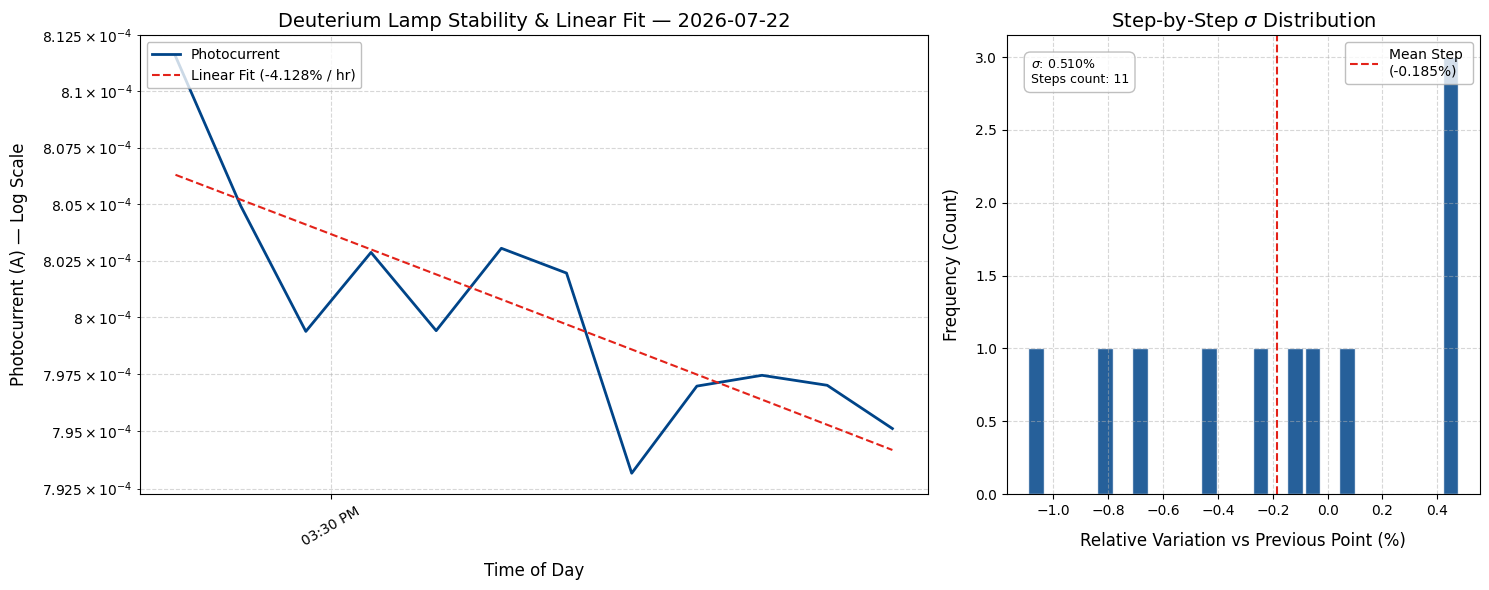

In [113]:
# SAME THING - DATA TAKEN 2026/07/22

import os
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# LOAD DATA
path_file = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\test_stability_20260722_no3_long.txt"
df = pd.read_csv(path_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# FILTER DATA (Start at 10:25 AM,when lamp is "stable")
df_filtered = df[df['t_min'] >= 15.0].copy()

# CALCULATE LINEAR FIT & SLOPE IN %
# Convert filtered timestamps to numerical minutes/hours from the new start point
time_minutes = df_filtered['t_min'].values - df_filtered['t_min'].min()
time_hours = time_minutes / 60.0
current_vals = df_filtered['current_mean_A'].values

# Fit a first-degree polynomial (straight line): y = mx + c
slope, intercept = np.polyfit(time_hours, current_vals, 1)
fit_line = slope * time_hours + intercept

# Calculate relative slope percentage based on the global mean of this window
mean_current = np.mean(current_vals)
slope_pct_per_hour = (slope / mean_current) * 100
slope_pct_per_minute = slope_pct_per_hour / 60.0

# Extract info for the title
experiment_date = df_filtered['timestamp'].iloc[0].strftime('%Y-%m-%d')

print("LINEAR FIT REPORT")
print(f"New Start Time: {df_filtered['timestamp'].iloc[0].strftime('%I:%M %p')}")
print(f"Mean Current (Filtered Window): {mean_current:.6e} A")
print(f"Absolute Slope: {slope:.6e} A/hour")
print(f"Relative Slope (%): {slope_pct_per_hour:.4f} % per hour")
print(f"Relative Slope (%): {slope_pct_per_minute:.6f} % per minute")

# COMPUTE POINT-BY-POINT RELATIVE DIFFERENCES
step_diffs = np.diff(current_vals)
relative_diffs_pct = (step_diffs / current_vals[:-1]) * 100
mean_step = np.mean(relative_diffs_pct)
std_step = np.std(relative_diffs_pct)

print("\nSTEP-TO-STEP VOLATILITY REPORT")
print(f"Number of steps analyzed: {len(relative_diffs_pct)}")
print(f"Average step variation: {mean_step:+.4f} %")
print(f"Step variation standard deviation: {std_step:.4f} %")

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1.2]})

# LEFT PLOT: Long-term Time Evolution & Drift
ax1.set_yscale('log')
ax1.plot(df_filtered['timestamp'], current_vals, color='#004488', linewidth=2, label='Photocurrent')
ax1.plot(df_filtered['timestamp'], fit_line, color='#e32219', linestyle='--', linewidth=1.5,
         label=f'Linear Fit ({slope_pct_per_hour:+.3f}% / hr)')

if (df_filtered['current_std_A'] > 0).any():
    ax1.fill_between(
        df_filtered['timestamp'],
        current_vals - df_filtered['current_std_A'],
        current_vals + df_filtered['current_std_A'],
        color='#004488', alpha=0.12, label='Uncertainty ($\\pm\\sigma$)'
    )

ax1.set_title(f'Deuterium Lamp Stability & Linear Fit — {experiment_date}', fontsize=14)
ax1.set_xlabel('Time of Day', fontsize=12, labelpad=10)
ax1.set_ylabel('Photocurrent (A) — Log Scale', fontsize=12, labelpad=10)
ax1.grid(True, which="both", linestyle='--', alpha=0.5, color='#b0b0b0')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax1.tick_params(axis='x', rotation=30)
ax1.legend(loc='upper left', frameon=True, edgecolor='#b0b0b0')

# RIGHT PLOT: Short-term Step Volatility Histogram
counts, bins, patches = ax2.hist(relative_diffs_pct, bins=25, color='#004488',
                                 edgecolor='white', alpha=0.85, rwidth=0.9)
ax2.axvline(mean_step, color='#e32219', linestyle='--', linewidth=1.5,
           label=f'Mean Step \n({mean_step:+.3f}%)')

ax2.set_title('Step-by-Step $\\sigma$ Distribution', fontsize=14)
ax2.set_xlabel('Relative Variation vs Previous Point (%)', fontsize=12, labelpad=10)
ax2.set_ylabel('Frequency (Count)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5, color='#b0b0b0')
ax2.legend(loc='upper right', frameon=True, edgecolor='#b0b0b0')

stats_box = f"$\\sigma$: {std_step:.3f}% \nSteps count: {len(relative_diffs_pct)}"
ax2.text(0.05, 0.95, stats_box, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#b0b0b0', alpha=0.8))

plt.tight_layout()

save_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\stability_5.65deg_2min_intervals_20260722.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

DAY-TO-DAY DRIFT ANALYSIS
At t = 99 min  -> Yesterday: 4.376111e-04 A | Today (no1): 2.126128e-05 A | Shift: -95.14 %
At t = 163 min -> Yesterday: 4.408625e-04 A | Today (no2): 2.134300e-05 A | Shift: -95.16 %
At t = 261 min -> Yesterday: 4.409228e-04 A | Today (no3): 1.538342e-03 A | Shift: +248.89 %


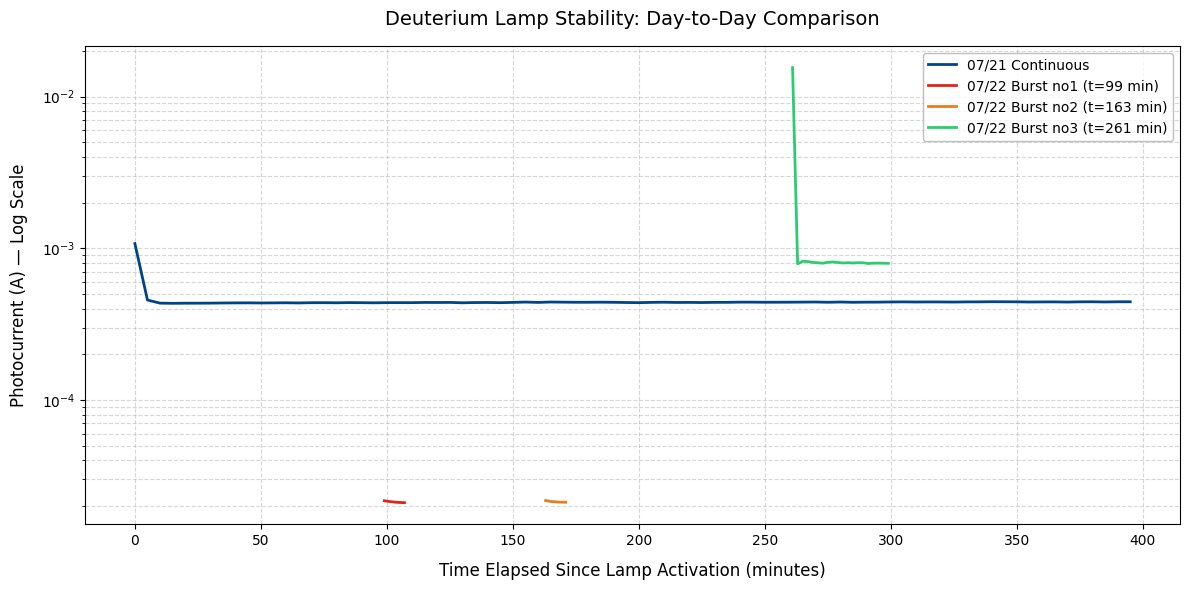

In [108]:
# DATA COMPARISON - 2026/07/21 & 2026/07/22 - OBVIOUSLY WE DID NOT USE THE SAME APERTURE

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# LOAD 2026/07/21 DATA
path_yesterday = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability\test_stability_20260721.txt"
df_yesterday = pd.read_csv(path_yesterday)

# LOAD 2026/07/22 DATA
base_dir = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Stability"

path_today_1 = os.path.join(base_dir, "test_stability_20260722_no1.txt")
path_today_2 = os.path.join(base_dir, "test_stability_20260722_no2.txt")
path_today_3 = os.path.join(base_dir, "test_stability_20260722_no3_long.txt")

df_today_1 = pd.read_csv(path_today_1)
df_today_2 = pd.read_csv(path_today_2)
df_today_3 = pd.read_csv(path_today_3)

# RECONSTRUCT TIME AXIS FOR 2026/07/22 DATA (2 min intervals)
# Burst 1: Starts at t = 99 min (5 points)
n_points_1 = len(df_today_1)
time_burst_1 = 99.0 + np.arange(n_points_1) * 2.0

# Burst 2: Starts at t = 163 min (5 points)
n_points_2 = len(df_today_2)
time_burst_2 = 163.0 + np.arange(n_points_2) * 2.0

# Burst 3: Starts at t = 261 min (20 points)
n_points_3 = len(df_today_3)
time_burst_3 = 261.0 + np.arange(n_points_3) * 2.0

# TENDENCY & VALUE COMPARISON
# Interpolate 2026/07/21 baseline value at exactly t = 99, 163 and 261 min
val_yes_at_99 = np.interp(99.0, df_yesterday['t_min'], df_yesterday['current_mean_A'])
val_yes_at_163 = np.interp(163.0, df_yesterday['t_min'], df_yesterday['current_mean_A'])
val_yes_at_261 = np.interp(261.0, df_yesterday['t_min'], df_yesterday['current_mean_A'])

mean_today_1 = df_today_1['current_mean_A'].mean()
mean_today_2 = df_today_2['current_mean_A'].mean()
mean_today_3 = df_today_3['current_mean_A'].mean()

# Calculate relative shifts (%)
shift_99_pct = ((mean_today_1 - val_yes_at_99) / val_yes_at_99) * 100
shift_163_pct = ((mean_today_2 - val_yes_at_163) / val_yes_at_163) * 100
shift_261_pct = ((mean_today_3 - val_yes_at_261) / val_yes_at_261) * 100

print("DAY-TO-DAY DRIFT ANALYSIS")
print(f"At t = 99 min  -> Yesterday: {val_yes_at_99:.6e} A | Today (no1): {mean_today_1:.6e} A | Shift: {shift_99_pct:+.2f} %")
print(f"At t = 163 min -> Yesterday: {val_yes_at_163:.6e} A | Today (no2): {mean_today_2:.6e} A | Shift: {shift_163_pct:+.2f} %")
print(f"At t = 261 min -> Yesterday: {val_yes_at_261:.6e} A | Today (no3): {mean_today_3:.6e} A | Shift: {shift_261_pct:+.2f} %")

# PLOTTING THE OVERLAY
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_yscale('log')

ax.plot(df_yesterday['t_min'], df_yesterday['current_mean_A'], color='#004488', linewidth=2, label='07/21 Continuous')
ax.plot(time_burst_1, df_today_1['current_mean_A'], color='#e32219', linewidth=2, markersize=4, label='07/22 Burst no1 (t=99 min)')
ax.plot(time_burst_2, df_today_2['current_mean_A'], color='#e67e22', linewidth=2, markersize=4, label='07/22 Burst no2 (t=163 min)')
ax.plot(time_burst_3, df_today_3['current_mean_A'], color='#2ecc71', linewidth=2, markersize=4, label='07/22 Burst no3 (t=261 min)')

ax.set_title('Deuterium Lamp Stability: Day-to-Day Comparison', fontsize=14, pad=15)
ax.set_xlabel('Time Elapsed Since Lamp Activation (minutes)', fontsize=12, labelpad=10)
ax.set_ylabel('Photocurrent (A) — Log Scale', fontsize=12, labelpad=10)

ax.grid(True, which="both", linestyle='--', alpha=0.5, color='#b0b0b0')
ax.legend(loc='upper right', frameon=True, edgecolor='#b0b0b0')

save_path = os.path.join(base_dir, "day_to_day_stability_overlay.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

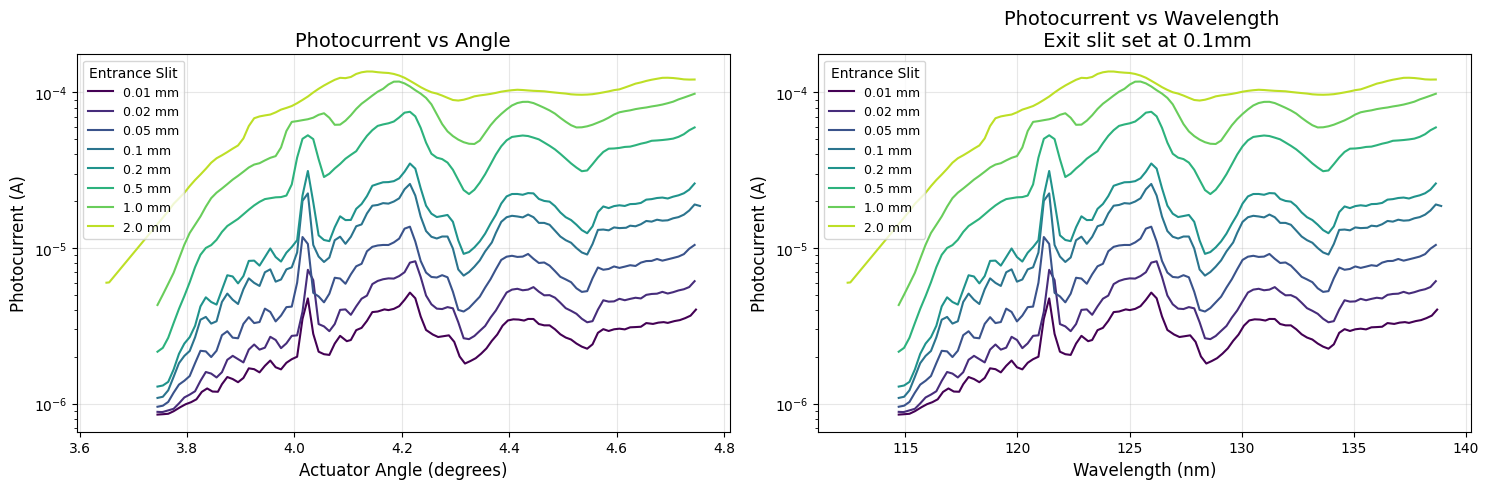

In [81]:
# 1ST RESOLUTION TEST - FIXED EXIT SLIT AND CHANGING THE ENTRANCE SLIT

import matplotlib.pyplot as plt
import numpy as np
import os

def actuator_angle_to_wavelength(theta_deg):
    d = 835.5          # nm (1 / 1200 lines/mm)
    phi = 35           # degrees (half deviation angle)
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1              # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)
    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Resolution"

filenames = [
    "resolution_3.75_4.75_0.01_0.01_0.1.txt",
    "resolution_3.75_4.75_0.01_0.02_0.1.txt",
    "resolution_3.75_4.75_0.01_0.05_0.1.txt",
    "resolution_3.75_4.75_0.01_0.1_0.1.txt",
    "resolution_3.75_4.75_0.01_0.2_0.1.txt",
    "resolution_3.75_4.75_0.01_0.5_0.1.txt",
    "resolution_3.75_4.75_0.01_1_0.1.txt",
    "resolution_3.75_4.75_0.01_2_0.1.txt",
]

def extract_slit(filename):
    match = re.search(r'0\.01_+([\d.]+)_0\.1\.txt', filename)
    return float(match.group(1)) if match else None

colors = plt.cm.viridis(np.linspace(0, 0.9, len(filenames)))

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i, filename in enumerate(filenames):
    filepath = os.path.join(base_path, filename)
    slit = extract_slit(filename)

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        angle = data[:, 0]
        photocurrent = data[:, 1]
        wavelength = actuator_angle_to_wavelength(angle)

        # Label with aperture value
        label = f"{slit} mm" if slit is not None else filename

        # Plot 1: Angle
        ax1.plot(angle, photocurrent, color=colors[i], linewidth=1.5, label=label)

        # Plot 2: Wavelength
        ax2.plot(wavelength, photocurrent, color=colors[i], linewidth=1.5, label=label)

    except Exception as e:
        print(f"Erreur: {filename} - {e}")

# Plot 1 config
ax1.set_xlabel('Actuator Angle (degrees)', fontsize=12)
ax1.set_ylabel('Photocurrent (A)', fontsize=12)
ax1.set_title('Photocurrent vs Angle', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend(title="Entrance Slit", fontsize=9)

# Plot 2 config
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Photocurrent (A)', fontsize=12)
ax2.set_title('Photocurrent vs Wavelength \n Exit slit set at 0.1mm', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend(title="Entrance Slit", fontsize=9)

save_path = os.path.join(base_path, "resolution_comparison_aperture_entrance_slit.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

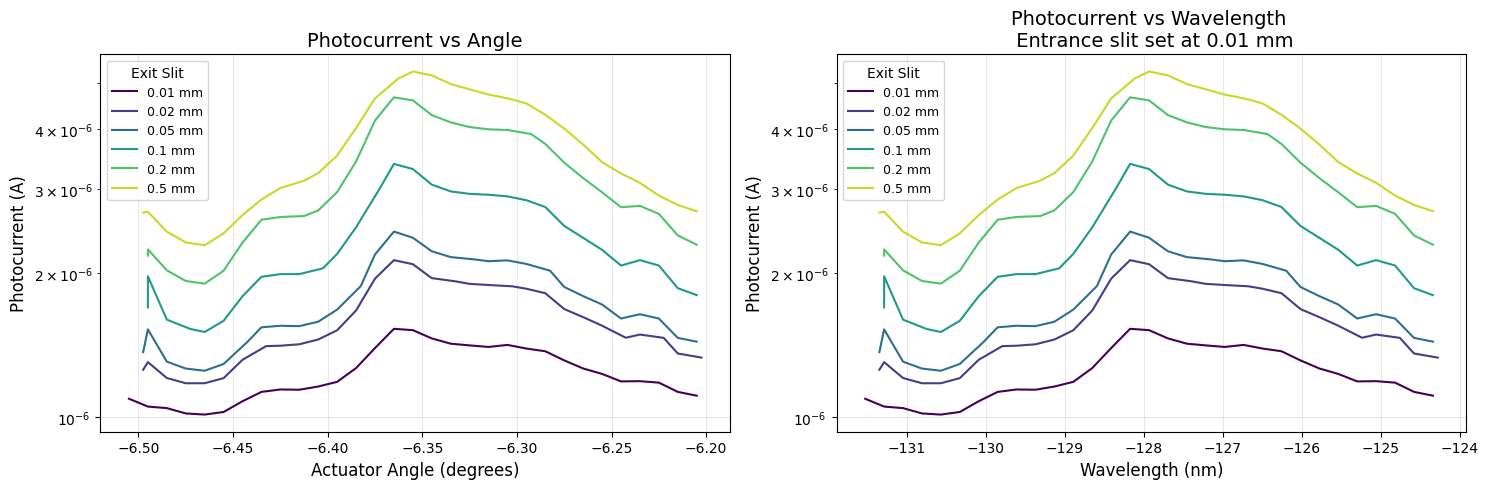

In [82]:
# 2ND RESOLUTION TEST - FIXED ENTRANCE SLIT AND CHANGING THE EXIT SLIT

import matplotlib.pyplot as plt
import numpy as np
import os

def actuator_angle_to_wavelength(theta_deg):
    d = 835.5          # nm (1 / 1200 lines/mm)
    phi = 35           # degrees (half deviation angle)
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1              # first diffraction order

    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0)
    phi_rad = np.radians(phi)

    C = 2 * d * np.cos(phi_rad)
    wavelength = (C * np.sin(gamma * (theta_rad - theta0_rad))) / m

    return wavelength

base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Resolution"

filenames = ["resolution_-6.5_-6.2_0.01_0.01_0.01.txt",
             "resolution_-6.5_-6.2_0.01_0.01_0.02.txt",
             "resolution_-6.5_-6.2_0.01_0.01_0.05.txt",
             "resolution_-6.5_-6.2_0.01_0.01_0.1.txt",
             "resolution_-6.5_-6.2_0.01_0.01_0.2.txt",
             "resolution_-6.5_-6.2_0.01_0.01_0.5.txt"
             ]

def extract_slit(filename):
    # Capture le dernier nombre avant .txt
    match = re.search(r'_([\d.]+)\.txt$', filename)
    return float(match.group(1)) if match else None


colors = plt.cm.viridis(np.linspace(0, 0.9, len(filenames)))

# PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i, filename in enumerate(filenames):
    filepath = os.path.join(base_path, filename)
    slit = extract_slit(filename)

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        angle = data[:, 0]
        photocurrent = data[:, 1]
        wavelength = actuator_angle_to_wavelength(angle)

        # Label with aperture value
        label = f"{slit} mm" if slit is not None else filename

        # Plot 1: Angle
        ax1.plot(angle, photocurrent, color=colors[i], linewidth=1.5, label=label)

        # Plot 2: Wavelength
        ax2.plot(wavelength, photocurrent, color=colors[i], linewidth=1.5, label=label)

    except Exception as e:
        print(f"Erreur: {filename} - {e}")

# Plot 1 config
ax1.set_xlabel('Actuator Angle (degrees)', fontsize=12)
ax1.set_ylabel('Photocurrent (A)', fontsize=12)
ax1.set_title('Photocurrent vs Angle', fontsize=14)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend(title="Exit Slit", fontsize=9)

# Plot 2 config
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Photocurrent (A)', fontsize=12)
ax2.set_title('Photocurrent vs Wavelength \n Entrance slit set at 0.01 mm', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend(title="Exit Slit", fontsize=9)

save_path = os.path.join(base_path, "resolution_comparison_aperture_exit_slit.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

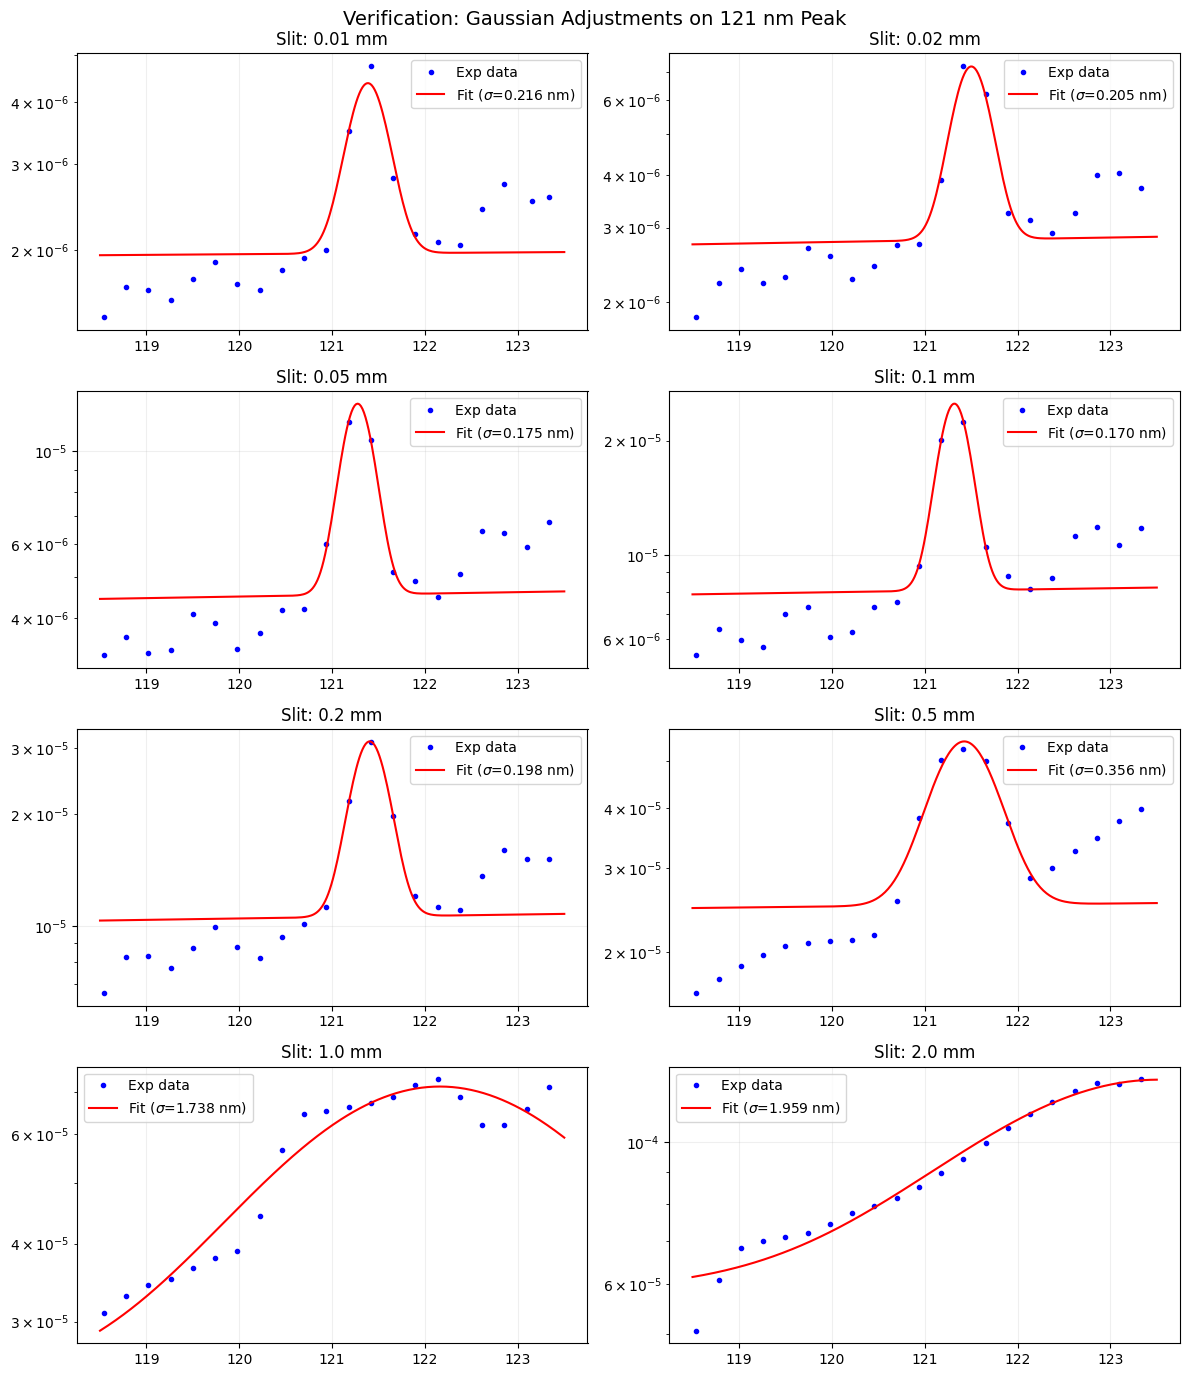

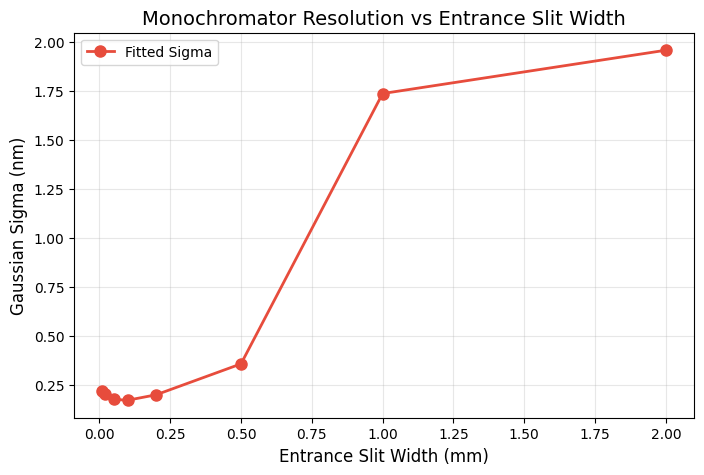

In [89]:
# RESOLUTION TEST ANALYSIS - ENTRANCE SLIT VARIATION, EXIT SLIT FIXED - INITIAL CHECK, DIFFERENT PEAK THAN THE 2 NEXT CELLS

import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import curve_fit

def actuator_angle_to_wavelength(theta_deg):
    d = 835.5          # nm
    phi = 35           # degrees
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1
    C = 2 * d * np.cos(np.radians(phi))
    return (C * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))) / m

def gaussian_with_background(x, amp, xo, sigma, slope, intercept):
    return amp * np.exp(-((x - xo) ** 2) / (2 * sigma ** 2)) + (slope * x + intercept)

base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Resolution"

filenames = [
    "resolution_3.75_4.75_0.01_0.01_0.1.txt",
    "resolution_3.75_4.75_0.01_0.02_0.1.txt",
    "resolution_3.75_4.75_0.01_0.05_0.1.txt",
    "resolution_3.75_4.75_0.01_0.1_0.1.txt",
    "resolution_3.75_4.75_0.01_0.2_0.1.txt",
    "resolution_3.75_4.75_0.01_0.5_0.1.txt",
    "resolution_3.75_4.75_0.01_1_0.1.txt",
    "resolution_3.75_4.75_0.01_2_0.1.txt"
]

def extract_slit(filename):
    match = re.search(r'0\.01_+([\d.]+)_0\.1\.txt', filename)
    return float(match.group(1)) if match else None

WL_MIN = 118.5
WL_MAX = 123.5

slit_sizes = []
sigmas = []

fig_check, axes_check = plt.subplots(4, 2, figsize=(12, 14))
axes_flat = axes_check.flatten()

for i, filename in enumerate(filenames):
    filepath = os.path.join(base_path, filename)
    slit = extract_slit(filename)
    if slit is None:
        continue

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        wavelength = actuator_angle_to_wavelength(data[:, 0])
        photocurrent = data[:, 1]

        mask = (wavelength >= WL_MIN) & (wavelength <= WL_MAX)
        w_cut = wavelength[mask]
        p_cut = photocurrent[mask]

        if len(w_cut) < 5:
            print(f"Attention : aucun point dans la zone [{WL_MIN}-{WL_MAX} nm] pour {filename}")
            continue

        xo_init = w_cut[np.argmax(p_cut)]
        initial_guess = [np.max(p_cut) - np.min(p_cut), xo_init, 0.4, 0.0, np.min(p_cut)]

        bounds = ([0, WL_MIN, 0.01, -1e-3, 0], [np.max(p_cut)*2, WL_MAX, 5.0, 1e-3, np.max(p_cut)])

        popt, _ = curve_fit(gaussian_with_background, w_cut, p_cut, p0=initial_guess, bounds=bounds)

        slit_sizes.append(slit)
        sigmas.append(popt[2])

        ax = axes_flat[i]
        ax.plot(w_cut, p_cut, 'b.', label='Exp data')

        w_fine = np.linspace(WL_MIN, WL_MAX, 300)
        ax.plot(w_fine, gaussian_with_background(w_fine, *popt), 'r-', linewidth=1.5,
                label=f'Fit ($\\sigma$={popt[2]:.3f} nm)')

        ax.set_title(f"Slit: {slit} mm", fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=10)

    except Exception as e:
        print(f"Erreur sur {filename}: {e}")

fig_check.suptitle("Verification: Gaussian Adjustments on 121 nm Peak", fontsize=14, y=0.98)
fig_check.tight_layout()
fig_check.savefig(os.path.join(base_path, "verification_fits_121nm.png"), dpi=200)


# FINAL PLOT
if len(slit_sizes) > 0:
    sort_idx = np.argsort(slit_sizes)
    slit_sizes = np.array(slit_sizes)[sort_idx]
    sigmas = np.array(sigmas)[sort_idx]

    plt.figure(figsize=(8, 5))

    plt.plot(slit_sizes, sigmas, 'o-', color='#e74c3c', linewidth=2, markersize=8, label="Fitted Sigma")

    plt.xlabel('Entrance Slit Width (mm)', fontsize=12)
    plt.ylabel('Gaussian Sigma (nm)', fontsize=12)

    plt.title("Monochromator Resolution vs Entrance Slit Width", fontsize=14)

    plt.grid(True, which="both", alpha=0.3)
    plt.legend(loc="upper left")

    save_path_final = os.path.join(base_path, "resolution_sigma_vs_entrance_slit_121nm.png")
    plt.savefig(save_path_final, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n[ERREUR] Aucun fichier n'a pu être traité.")

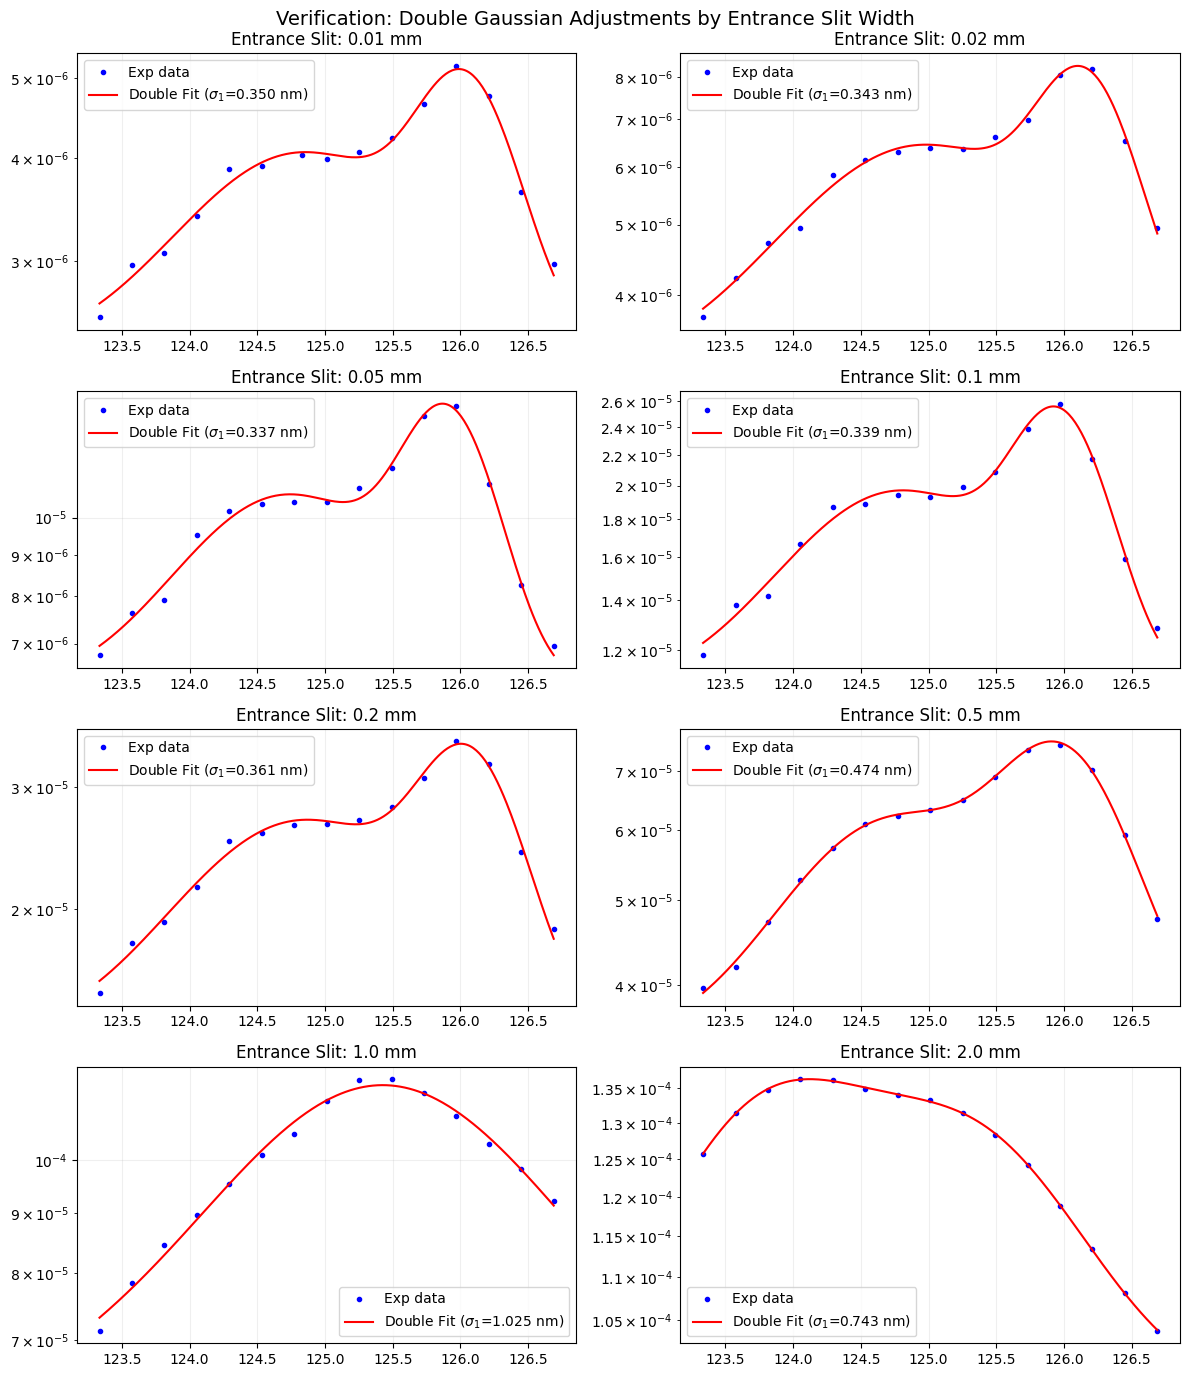

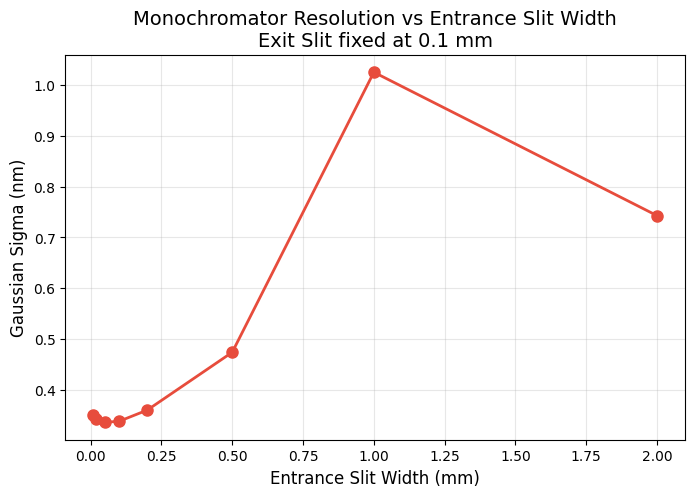

In [86]:
# RESOLUTION TEST ANALYSIS - ENTRANCE SLIT VARIATION, EXIT SLIT FIXED

import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import curve_fit

def actuator_angle_to_wavelength(theta_deg):
    d = 835.5          # nm
    phi = 35           # degrees
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1
    C = 2 * d * np.cos(np.radians(phi))
    return (C * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))) / m

def double_gaussian_with_background(x, amp1, xo1, sigma1, amp2, xo2, sigma2, slope, intercept):
    g1 = amp1 * np.exp(-((x - xo1) ** 2) / (2 * sigma1 ** 2))
    g2 = amp2 * np.exp(-((x - xo2) ** 2) / (2 * sigma2 ** 2))
    return g1 + g2 + (slope * x + intercept)

base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Resolution"

filenames = [
    "resolution_3.75_4.75_0.01_0.01_0.1.txt",
    "resolution_3.75_4.75_0.01_0.02_0.1.txt",
    "resolution_3.75_4.75_0.01_0.05_0.1.txt",
    "resolution_3.75_4.75_0.01_0.1_0.1.txt",
    "resolution_3.75_4.75_0.01_0.2_0.1.txt",
    "resolution_3.75_4.75_0.01_0.5_0.1.txt",
    "resolution_3.75_4.75_0.01_1_0.1.txt",
    "resolution_3.75_4.75_0.01_2_0.1.txt"
]

def extract_slit(filename):
    match = re.search(r'0\.01_+([\d.]+)_0\.1\.txt', filename)
    return float(match.group(1)) if match else None

# STRICT TARGET IN ANGLE (+ CONVERSION IN WAVELENGTH FOR THE MASK AND FIT)
ANGLE_MIN = 4.10
ANGLE_MAX = 4.25

WL_MIN = actuator_angle_to_wavelength(ANGLE_MIN)
WL_MAX = actuator_angle_to_wavelength(ANGLE_MAX)

slit_sizes = []
sigmas_main = []

# 4x2 grid for 8 files
fig_check, axes_check = plt.subplots(4, 2, figsize=(12, 14))
axes_flat = axes_check.flatten()

for i, filename in enumerate(filenames):
    filepath = os.path.join(base_path, filename)
    slit = extract_slit(filename)
    if slit is None:
        continue

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        angles = data[:, 0]
        wavelength = actuator_angle_to_wavelength(angles)
        photocurrent = data[:, 1]

        # Mask for the RoI
        mask = (angles >= ANGLE_MIN) & (angles <= ANGLE_MAX)
        w_cut = wavelength[mask]
        p_cut = photocurrent[mask]

        if len(w_cut) < 8:
            print(f"Warning: Not enough points in the target area to {filename}")
            continue

        # Finding the position of the vertex within the cropped area
        idx_max = np.argmax(p_cut)
        xo_max_wl = w_cut[idx_max]

        wl_lower = min(w_cut.min(), w_cut.max())
        wl_upper = max(w_cut.min(), w_cut.max())

        xo1_init = xo_max_wl
        xo2_init = (wl_lower + wl_upper) / 2.0

        amp1_init = np.max(p_cut) - np.min(p_cut)
        amp2_init = amp1_init * 0.5

        initial_guess = [
            amp1_init, xo1_init, 0.4,  # Pic 1
            amp2_init, xo2_init, 0.5,  # Pic 2
            0.0, np.min(p_cut)         # Fond linéaire
        ]

        bounds = (
            [0, wl_lower - 1.0, 0.02,  0, wl_lower - 1.0, 0.02, -1e-2, 0],
            [amp1_init * 3, wl_upper + 1.0, 4.0,  amp1_init * 3, wl_upper + 1.0, 4.0,  1e-2, np.max(p_cut)]
        )

        popt, _ = curve_fit(double_gaussian_with_background, w_cut, p_cut, p0=initial_guess, bounds=bounds)

        wl_lower = min(WL_MIN, WL_MAX)
        wl_upper = max(WL_MIN, WL_MAX)

        bounds = (
            [0, wl_lower, 0.02,  0, wl_lower, 0.02, -1e-3, 0],
            [amp1_init * 2, wl_upper, 4.0,  amp1_init * 2, wl_upper, 4.0,  1e-3, np.max(p_cut)]
        )

        popt, _ = curve_fit(double_gaussian_with_background, w_cut, p_cut, p0=initial_guess, bounds=bounds)

        # Extraction of the sigma value from the main peak
        slit_sizes.append(slit)
        sigmas_main.append(popt[2])

        # Interim Control Plot
        ax = axes_flat[i]
        ax.plot(w_cut, p_cut, 'b.', label='Exp data')

        w_fine = np.linspace(w_cut.min(), w_cut.max(), 300)
        ax.plot(w_fine, double_gaussian_with_background(w_fine, *popt), 'r-', linewidth=1.5,
                label=f'Double Fit ($\\sigma_1$={popt[2]:.3f} nm)')

        ax.set_title(f"Entrance Slit: {slit} mm", fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=10)

    except Exception as e:
        print(f"Error on {filename}: {e}")

fig_check.suptitle("Verification: Double Gaussian Adjustments by Entrance Slit Width", fontsize=14, y=0.98)
fig_check.tight_layout()
fig_check.savefig(os.path.join(base_path, "verification_fits_entrance_slits_double_gauss.png"), dpi=200)

# FINAL PLOT
if len(slit_sizes) > 0:
    sort_idx = np.argsort(slit_sizes)
    slit_sizes = np.array(slit_sizes)[sort_idx]
    sigmas_main = np.array(sigmas_main)[sort_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(slit_sizes, sigmas_main, 'o-', color='#e74c3c', linewidth=2, markersize=8, label="Main Peak Sigma")

    plt.xlabel('Entrance Slit Width (mm)', fontsize=12)
    plt.ylabel('Gaussian Sigma (nm)', fontsize=12)
    plt.title("Monochromator Resolution vs Entrance Slit Width\nExit Slit fixed at 0.1 mm", fontsize=14)

    plt.grid(True, which="both", alpha=0.3)

    save_path_final = os.path.join(base_path, "resolution_sigma_vs_entrance_slit_double_gauss.png")
    plt.savefig(save_path_final, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n[ERROR] No files could be processed. Check the angles or the conversion to WL.")

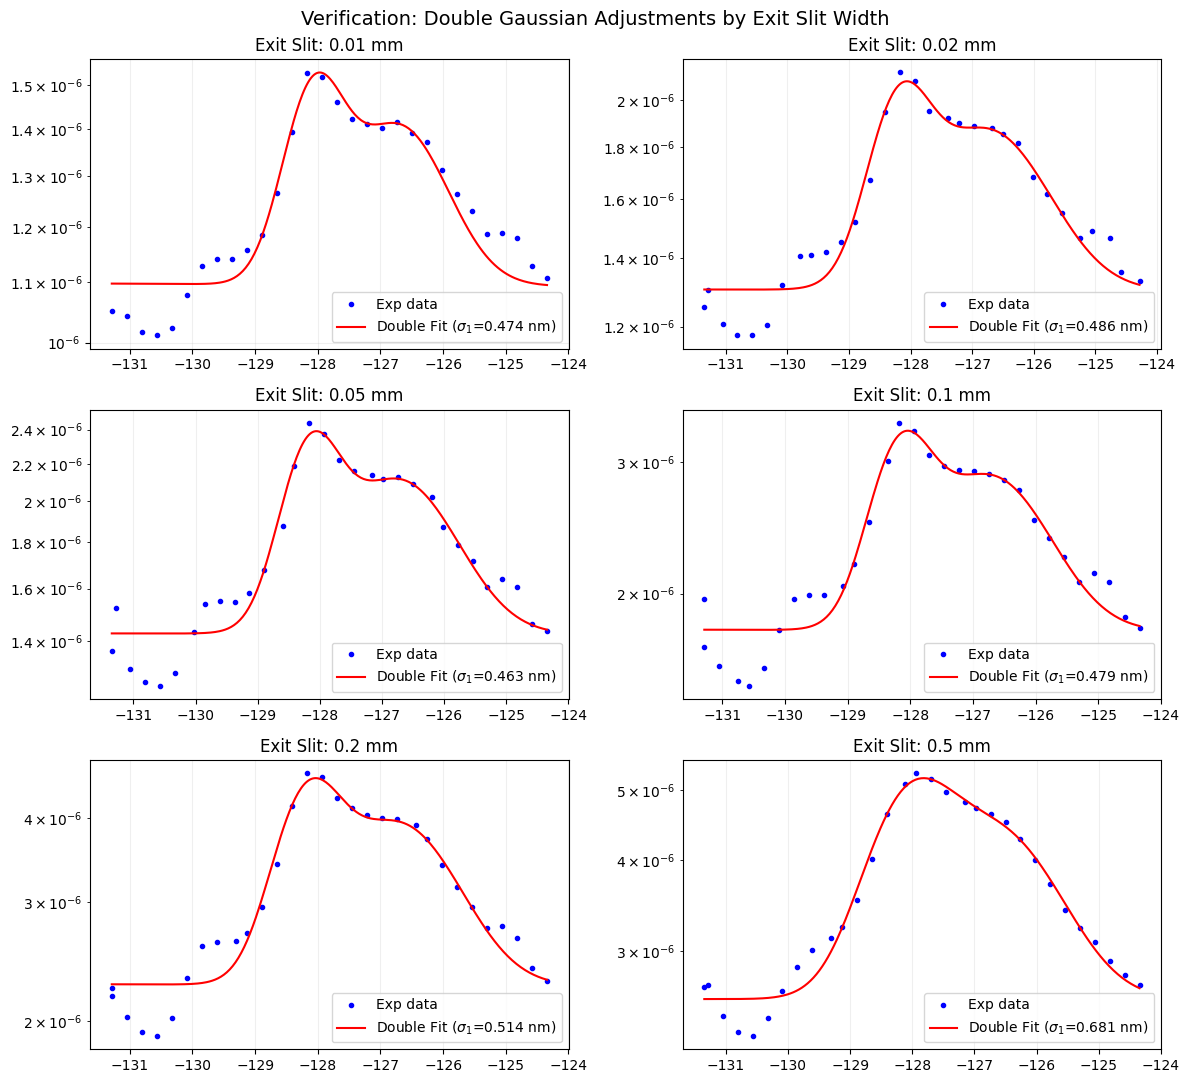

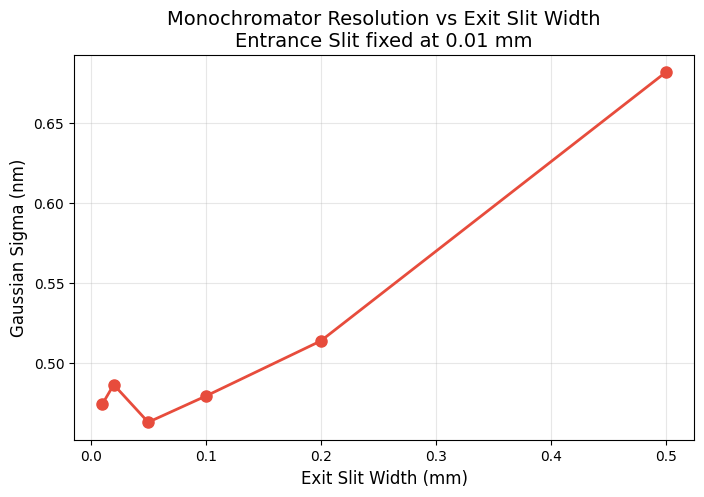

In [88]:
# RESOLUTION TEST ANALYSIS - EXIT SLIT VARIATION, ENTRANCE SLIT FIXED

import matplotlib.pyplot as plt
import numpy as np
import os
import re
from scipy.optimize import curve_fit

def actuator_angle_to_wavelength(theta_deg):
    d = 835.5          # nm
    phi = 35           # degrees
    gamma = 1.00694    # actuator scaling factor
    theta0 = -1.02898  # degrees (angular offset)
    m = 1
    C = 2 * d * np.cos(np.radians(phi))
    return (C * np.sin(gamma * (np.radians(theta_deg) - np.radians(theta0)))) / m

def double_gaussian_with_background(x, amp1, xo1, sigma1, amp2, xo2, sigma2, slope, intercept):
    g1 = amp1 * np.exp(-((x - xo1) ** 2) / (2 * sigma1 ** 2))
    g2 = amp2 * np.exp(-((x - xo2) ** 2) / (2 * sigma2 ** 2))
    return g1 + g2 + (slope * x + intercept)

base_path = r"C:\Users\leaga\OneDrive\Desktop\Internship UoM\VUV Monochromator\2. Deuterium Lamp\Resolution"

filenames = [
    "resolution_-6.5_-6.2_0.01_0.01_0.01.txt",
    "resolution_-6.5_-6.2_0.01_0.01_0.02.txt",
    "resolution_-6.5_-6.2_0.01_0.01_0.05.txt",
    "resolution_-6.5_-6.2_0.01_0.01_0.1.txt",
    "resolution_-6.5_-6.2_0.01_0.01_0.2.txt",
    "resolution_-6.5_-6.2_0.01_0.01_0.5.txt"
]

def extract_slit(filename):
    match = re.search(r'0\.01_([\d.]+)\.txt$', filename)
    return float(match.group(1)) if match else None

WL_MIN = -131.5
WL_MAX = -124.0

slit_sizes = []
sigmas_main = []

fig_check, axes_check = plt.subplots(3, 2, figsize=(12, 11))
axes_flat = axes_check.flatten()

for i, filename in enumerate(filenames):
    filepath = os.path.join(base_path, filename)
    slit = extract_slit(filename)
    if slit is None:
        continue

    try:
        data = np.loadtxt(filepath, delimiter=',', usecols=(0, 1))
        wavelength = actuator_angle_to_wavelength(data[:, 0])
        photocurrent = data[:, 1]

        mask = (wavelength >= WL_MIN) & (wavelength <= WL_MAX)
        w_cut = wavelength[mask]
        p_cut = photocurrent[mask]

        if len(w_cut) < 8:
            continue

        xo1_init = -128.0
        xo2_init = -126.8

        amp1_init = np.max(p_cut) - np.min(p_cut)
        amp2_init = amp1_init * 0.7

        initial_guess = [
            amp1_init, xo1_init, 0.5,  # Peak 1
            amp2_init, xo2_init, 0.6,  # Peak 2
            0.0, np.min(p_cut)         # Background
        ]

        bounds = (
            [0, -129.5, 0.05,  0, -127.5, 0.05, -1e-3, 0],
            [amp1_init*2, -127.5, 3.0,  amp1_init*2, -125.0, 3.0,  1e-3, np.max(p_cut)]
        )

        popt, _ = curve_fit(double_gaussian_with_background, w_cut, p_cut, p0=initial_guess, bounds=bounds)

        # Extract sigma from the main peak
        slit_sizes.append(slit)
        sigmas_main.append(popt[2])

        # Interim Control Plots
        ax = axes_flat[i]
        ax.plot(w_cut, p_cut, 'b.', label='Exp data')

        w_fine = np.linspace(w_cut.min(), w_cut.max(), 300)
        ax.plot(w_fine, double_gaussian_with_background(w_fine, *popt), 'r-', linewidth=1.5,
                label=f'Double Fit ($\\sigma_1$={popt[2]:.3f} nm)')

        ax.set_title(f"Exit Slit: {slit} mm", fontsize=12)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=10)

    except Exception as e:
        print(f"Erreur sur {filename}: {e}")

fig_check.suptitle("Verification: Double Gaussian Adjustments by Exit Slit Width", fontsize=14, y=0.98)
fig_check.tight_layout()
fig_check.savefig(os.path.join(base_path, "verification_fits_exit_slit_double_gauss.png"), dpi=200)

# FINAL PLOT
if len(slit_sizes) > 0:
    sort_idx = np.argsort(slit_sizes)
    slit_sizes = np.array(slit_sizes)[sort_idx]
    sigmas_main = np.array(sigmas_main)[sort_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(slit_sizes, sigmas_main, 'o-', color='#e74c3c', linewidth=2, markersize=8, label="Main Peak Sigma")

    plt.xlabel('Exit Slit Width (mm)', fontsize=12)
    plt.ylabel('Gaussian Sigma (nm)', fontsize=12)
    plt.title("Monochromator Resolution vs Exit Slit Width\nEntrance Slit fixed at 0.01 mm", fontsize=14)

    plt.grid(True, which="both", alpha=0.3)

    save_path_final = os.path.join(base_path, "resolution_sigma_vs_exit_slit_double_gauss.png")
    plt.savefig(save_path_final, dpi=300, bbox_inches='tight')
    plt.show()